In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("Metro_Interstate_Traffic_Volume.csv")

In [3]:
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,02-10-2012 09:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,02-10-2012 10:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,02-10-2012 11:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,02-10-2012 12:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,02-10-2012 13:00,4918


In [4]:
df.shape

(48204, 9)

#### Check Dataset Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB


#### Statistical Summary Analysis

In [6]:
df.describe()

,temp,rain_1h,snow_1h,clouds_all,traffic_volume
count,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000
mean,281.205870,0.334264,0.000222,49.362231,3259.818355
std,13.338232,44.789133,0.008168,39.015750,1986.860670
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,272.160000,0.000000,0.000000,1.000000,1193.000000
50%,282.450000,0.000000,0.000000,64.000000,3380.000000
75%,291.806000,0.000000,0.000000,90.000000,4933.000000
max,310.070000,9831.300000,0.510000,100.000000,7280.000000


#### Missing Value Analysis

In [7]:
df.isnull().sum()

holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64

#### Handling Missing Values in Holiday Feature

In [8]:
df['holiday'] = df['holiday'].fillna("No Holiday")

#### Missing Values Verification

In [9]:
df.isnull().sum()

holiday                0
temp                   0
rain_1h                0
snow_1h                0
clouds_all             0
weather_main           0
weather_description    0
date_time              0
traffic_volume         0
dtype: int64

#### Duplicate Records Check

In [10]:
df.duplicated().sum()

np.int64(17)

#### Duplicate Records Removed

In [11]:
df = df.drop_duplicates()

#### Duplicate Records Verification

In [12]:
df.duplicated().sum()

np.int64(0)

## **Targeted Variable Analysis**

#### Target Variable Skewness Analysis

In [13]:
df['traffic_volume'].skew()

np.float64(-0.08906123810374801)

#### Traffic Volume Distribution Analysis

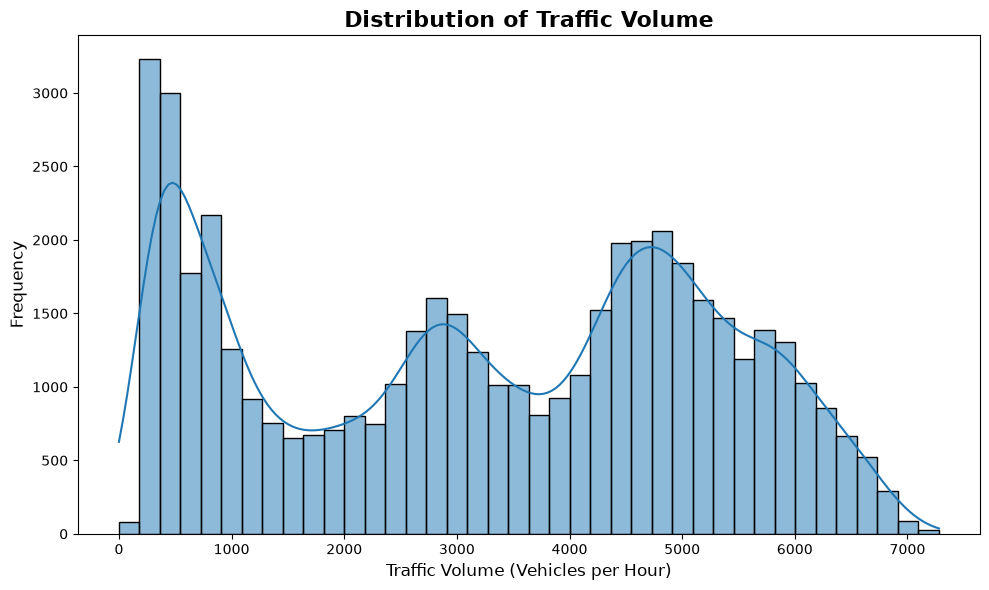

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='traffic_volume',
    bins=40,
    kde=True
)

plt.title('Distribution of Traffic Volume', fontsize=16, fontweight='bold')
plt.xlabel('Traffic Volume (Vehicles per Hour)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.tight_layout()
plt.show()

#### Target Variable Boxplot Analysis

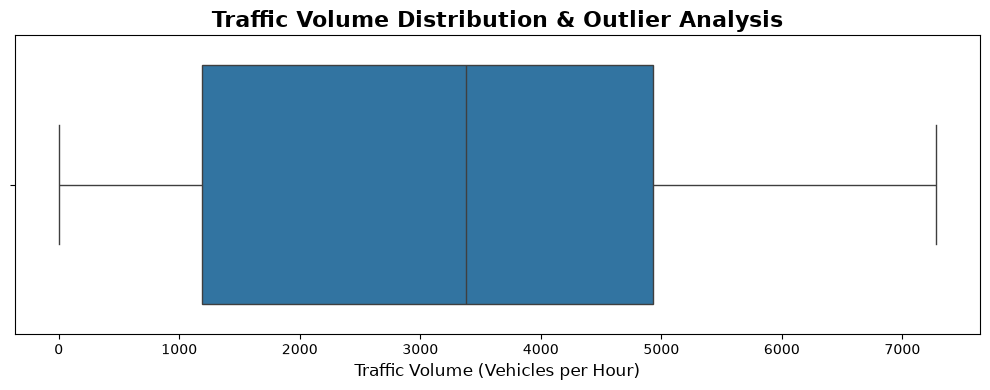

In [15]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df['traffic_volume']
)

plt.title('Traffic Volume Distribution & Outlier Analysis', fontsize=16, fontweight='bold')
plt.xlabel('Traffic Volume (Vehicles per Hour)', fontsize=12)

plt.tight_layout()
plt.show()

## **Univariate Analysis**

#### Numerical Features Distribution Analysis

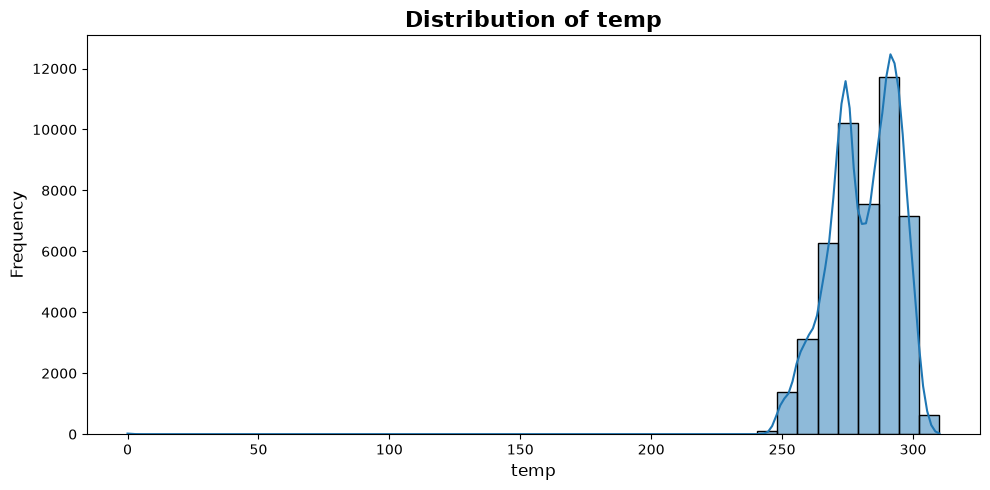

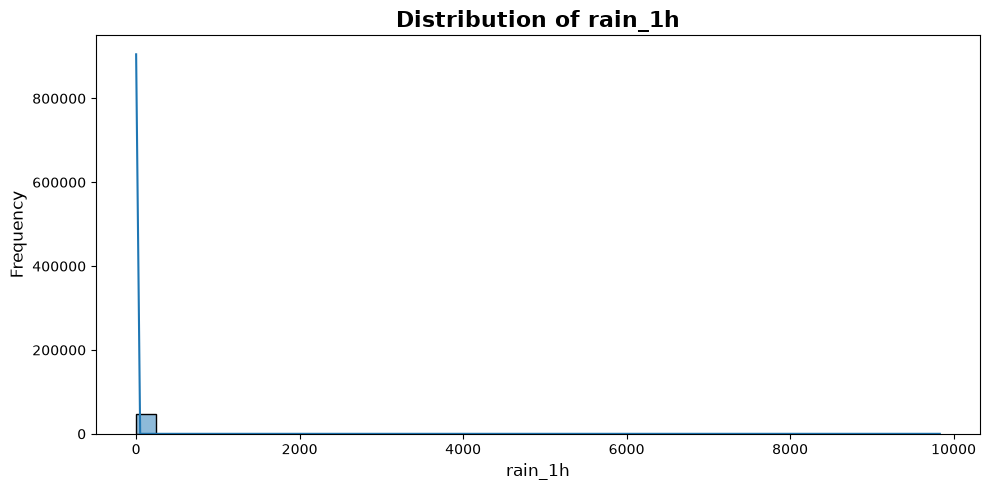

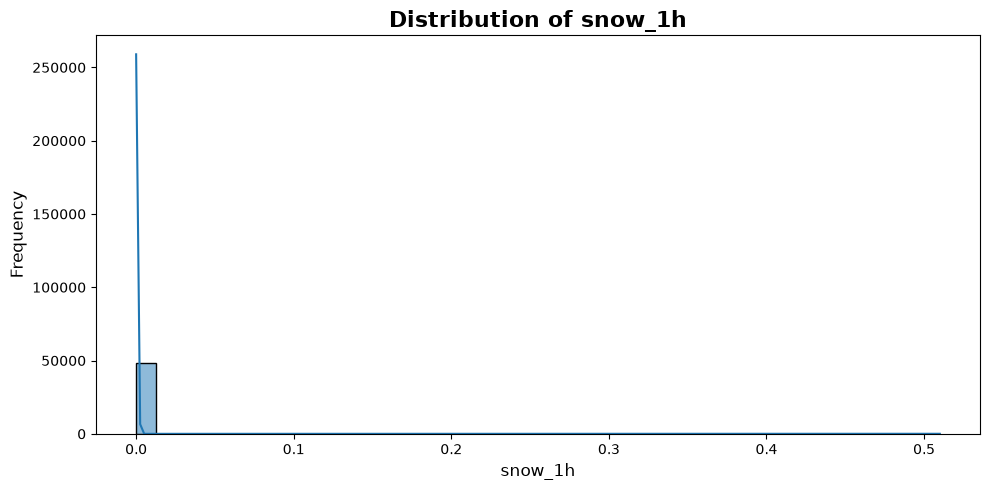

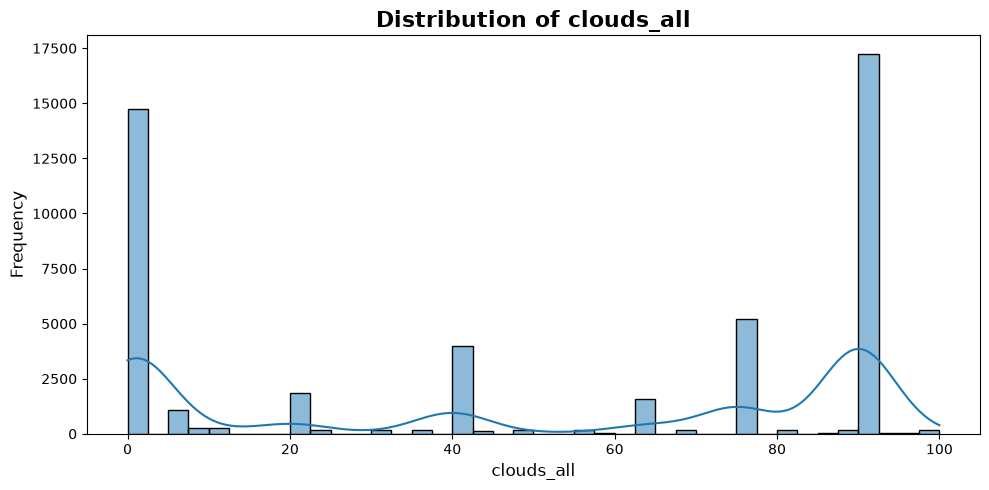

In [16]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('traffic_volume')

for col in num_cols:
    plt.figure(figsize=(10, 5))

    sns.histplot(
        data=df,
        x=col,
        bins=40,
        kde=True
    )

    plt.title(f'Distribution of {col}', fontsize=16, fontweight='bold')
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)

    plt.tight_layout()
    plt.show()

#### Categorical Feature Analysis

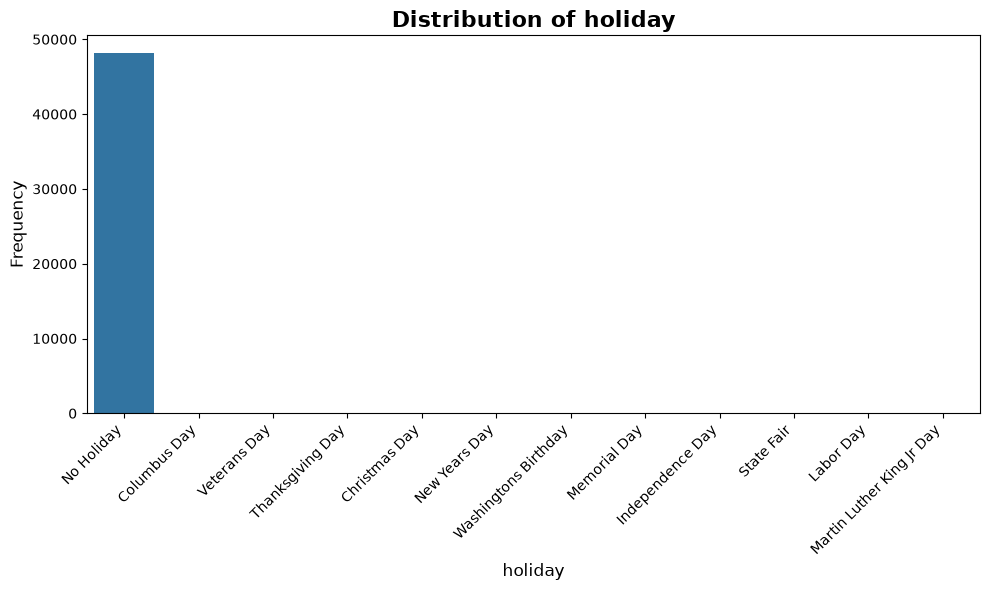

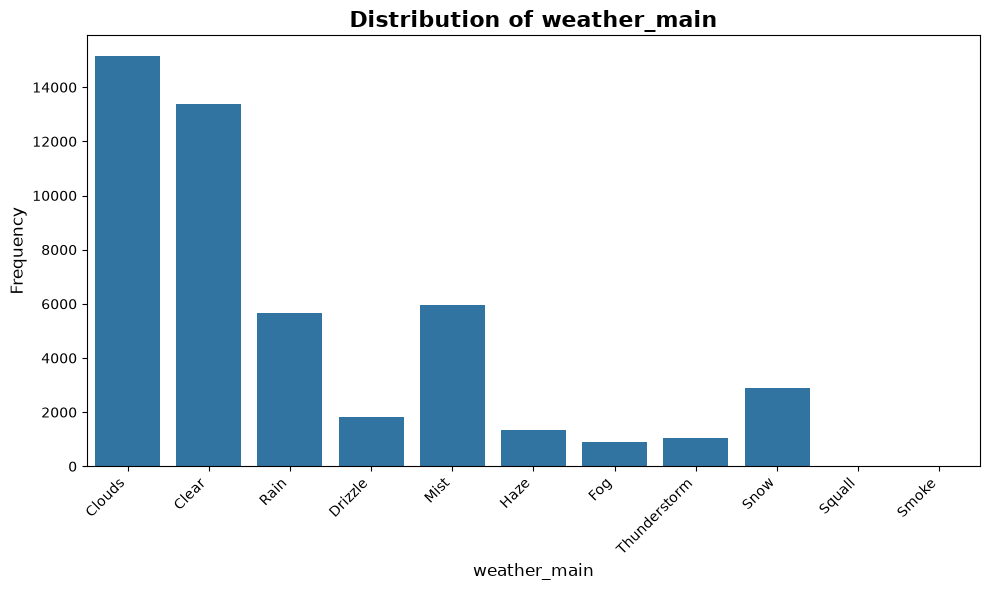

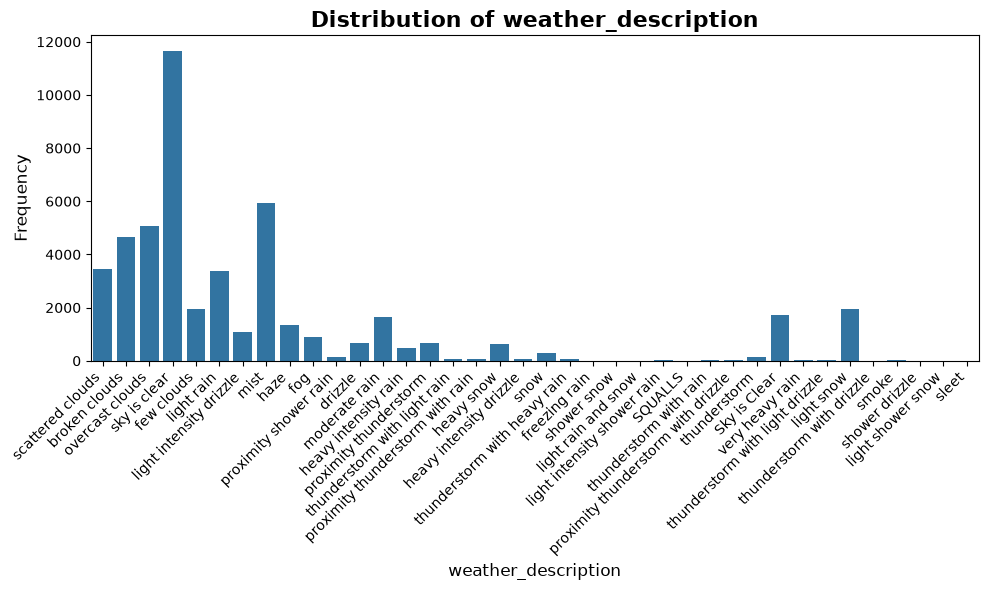

In [17]:
cat_cols = df.select_dtypes(include=['string', 'object']).columns.drop('date_time')

for col in cat_cols:
    plt.figure(figsize=(10, 6))

    sns.countplot(
        data=df,
        x=col
    )

    plt.title(f'Distribution of {col}', fontsize=16, fontweight='bold')
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)

    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    plt.show()

###

## **Bivariate  Analysis**

#### Numerical Features Correlation with Target Variable

In [18]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix['traffic_volume'].sort_values(ascending=False)

traffic_volume    1.000000
temp              0.130161
clouds_all        0.067138
rain_1h           0.004715
snow_1h           0.000736
Name: traffic_volume, dtype: float64

#### Numerical Features vs Target Variable Analysis

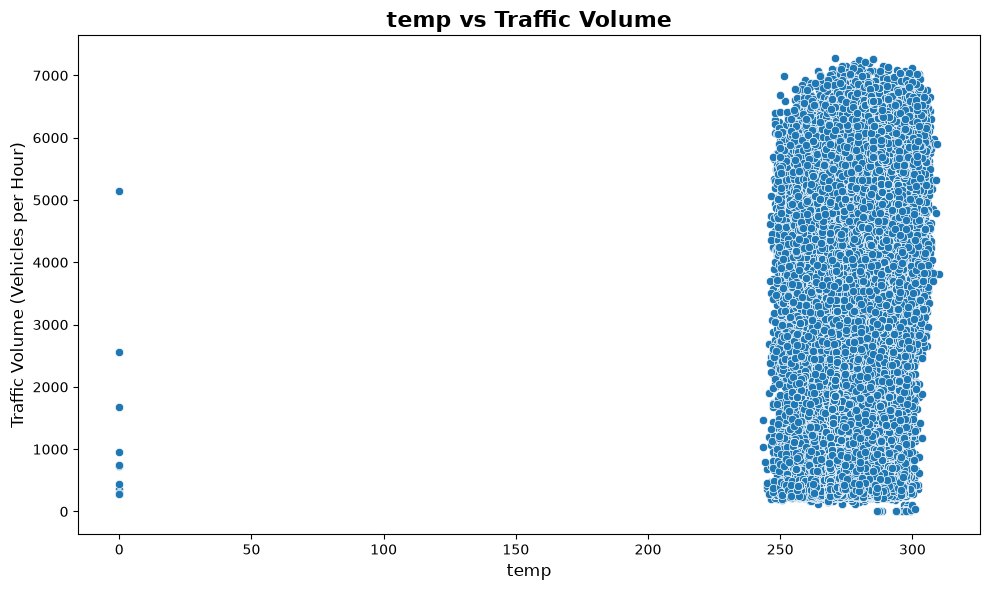

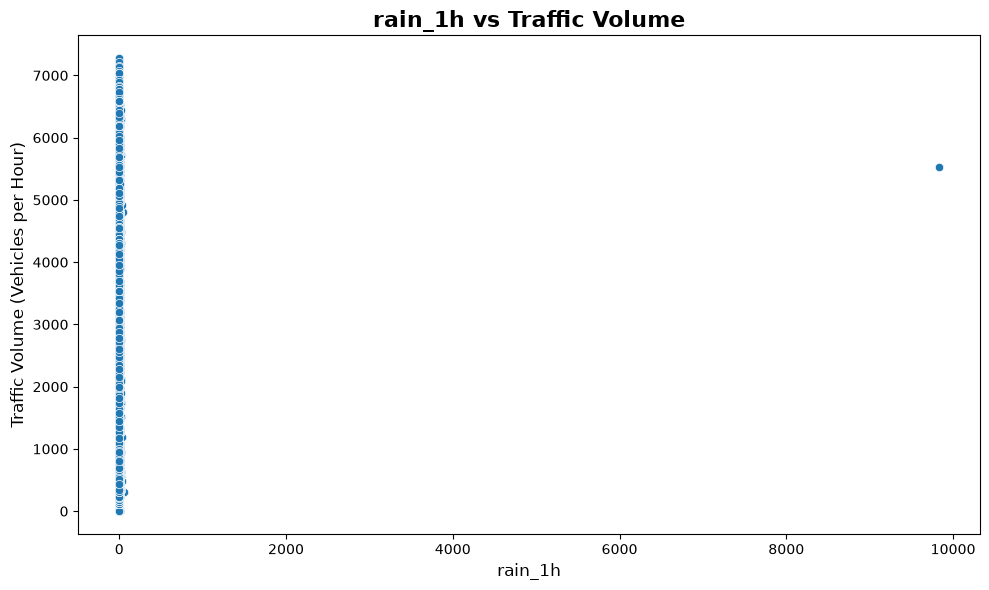

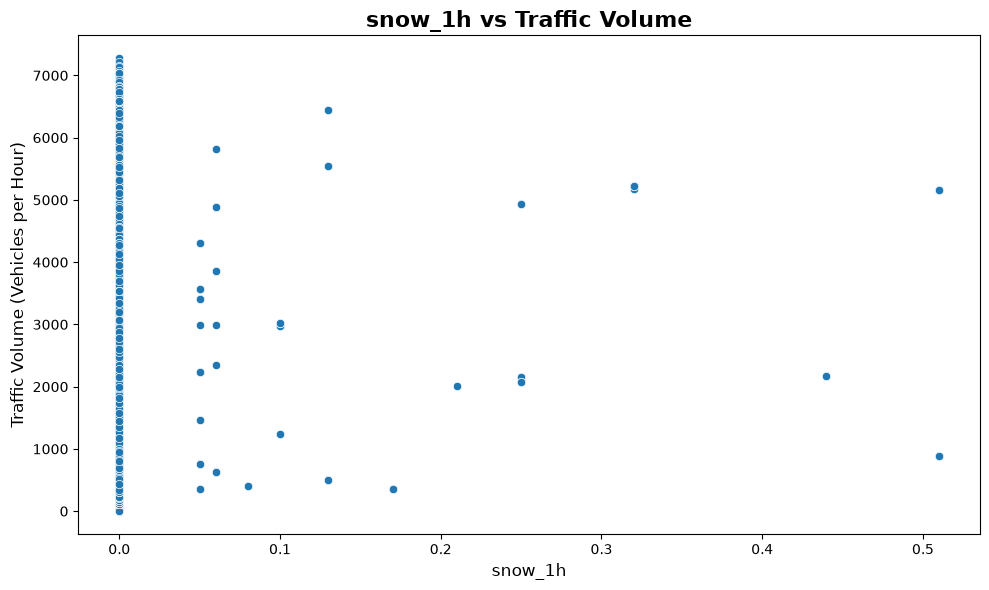

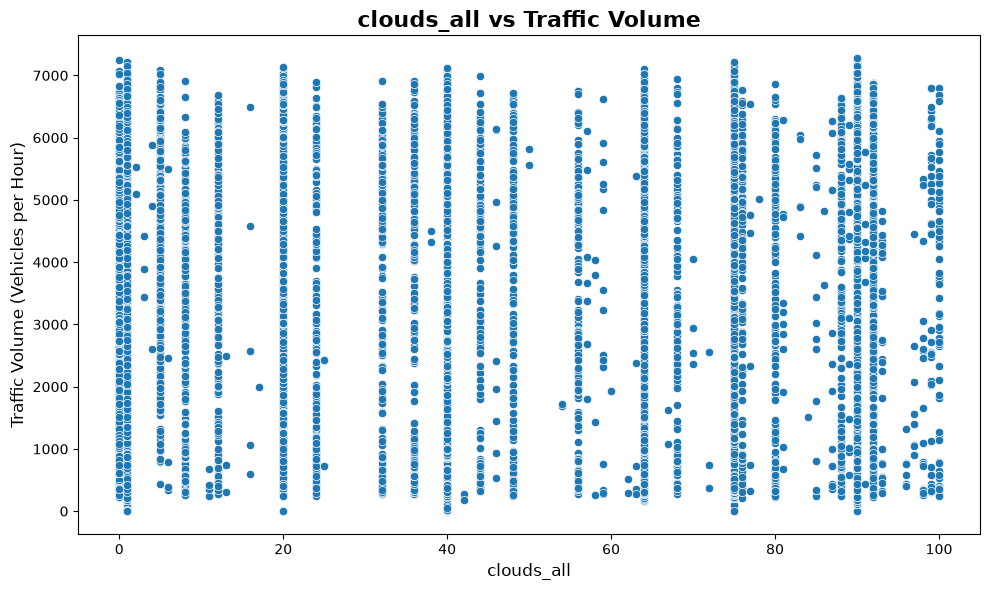

In [19]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('traffic_volume')

for col in num_cols:
    plt.figure(figsize=(10, 6))

    sns.scatterplot(
        data=df,
        x=col,
        y='traffic_volume'
    )

    plt.title(f'{col} vs Traffic Volume', fontsize=16, fontweight='bold')
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Traffic Volume (Vehicles per Hour)', fontsize=12)

    plt.tight_layout()
    plt.show()

#### Numerical Features Correlation Analysis

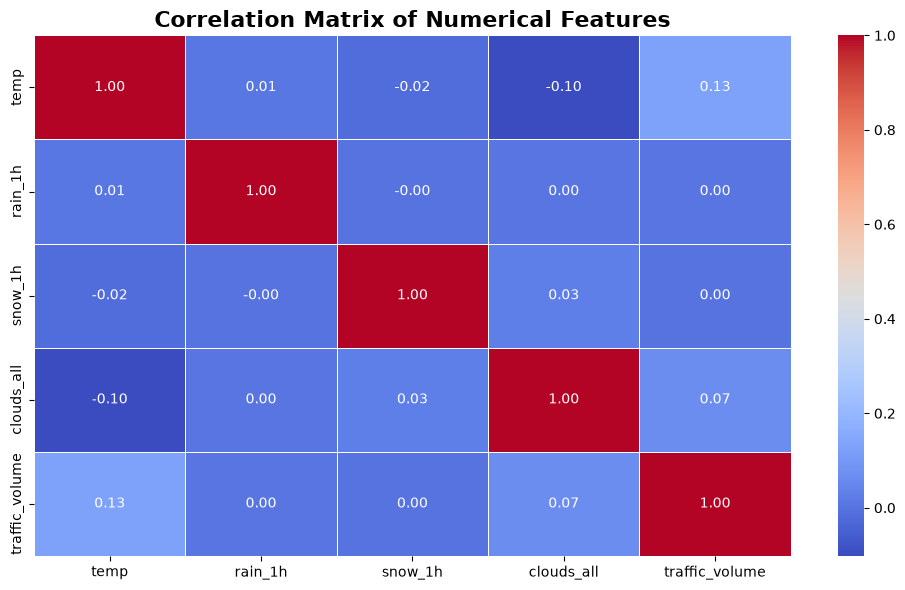

In [20]:
cols = ['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'traffic_volume']

plt.figure(figsize=(10, 6))

sns.heatmap(
    df[cols].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Matrix of Numerical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

#

#### Categorical Features vs Target Variable Analysis

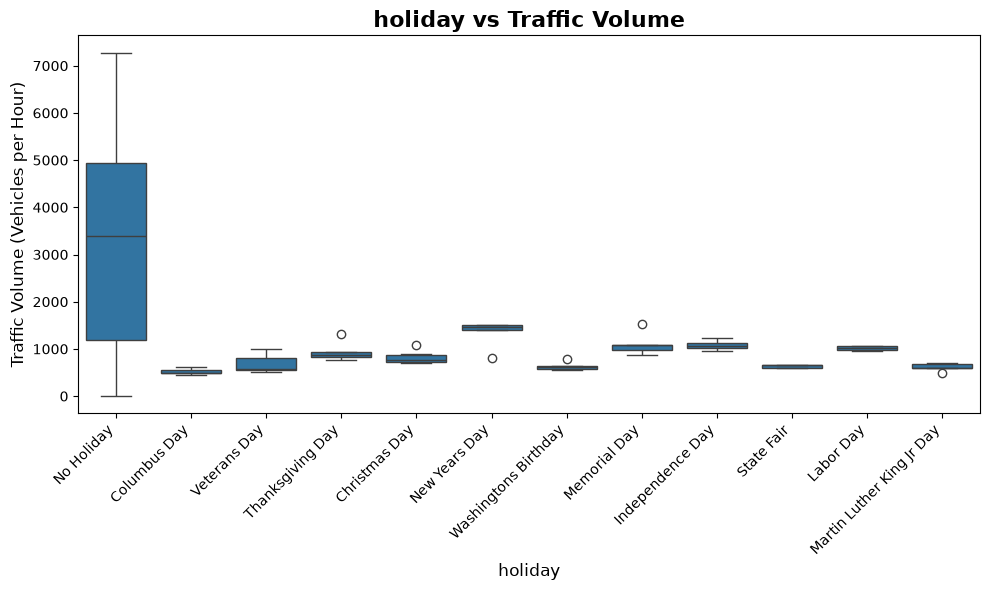

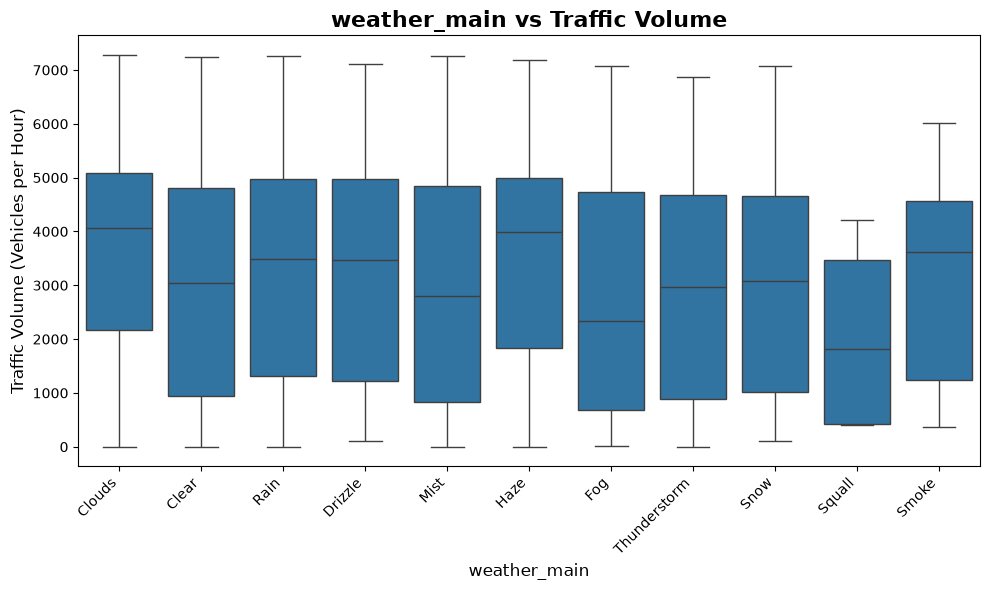

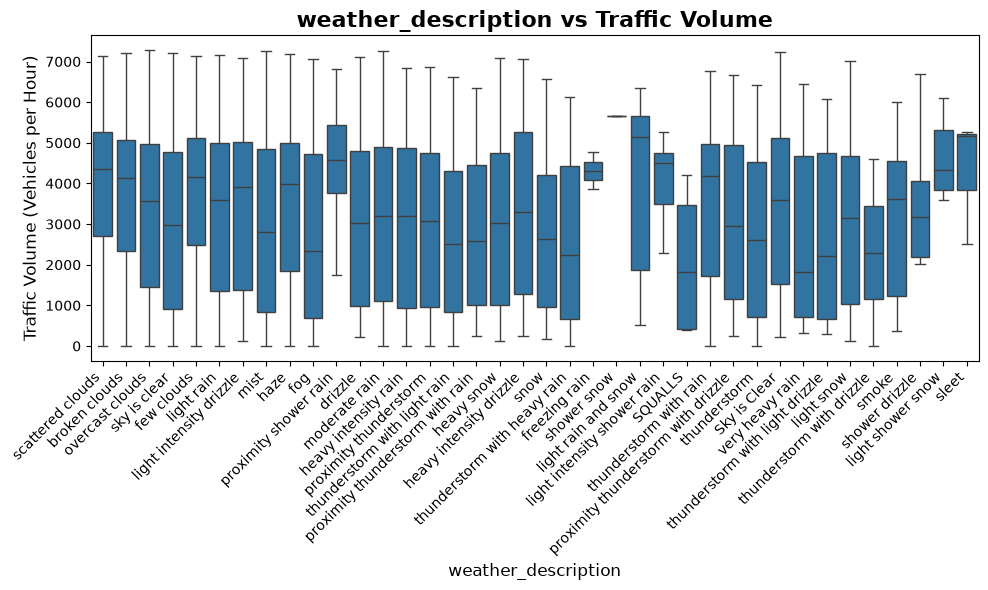

In [21]:
cat_cols = df.select_dtypes(include=['string', 'object']).columns.drop('date_time')

for col in cat_cols:
    plt.figure(figsize=(10, 6))

    sns.boxplot(
        data=df,
        x=col,
        y='traffic_volume'
    )

    plt.title(f'{col} vs Traffic Volume', fontsize=16, fontweight='bold')
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Traffic Volume (Vehicles per Hour)', fontsize=12)

    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    plt.show()    

#

#### Traffic Volume Time Series Analysis

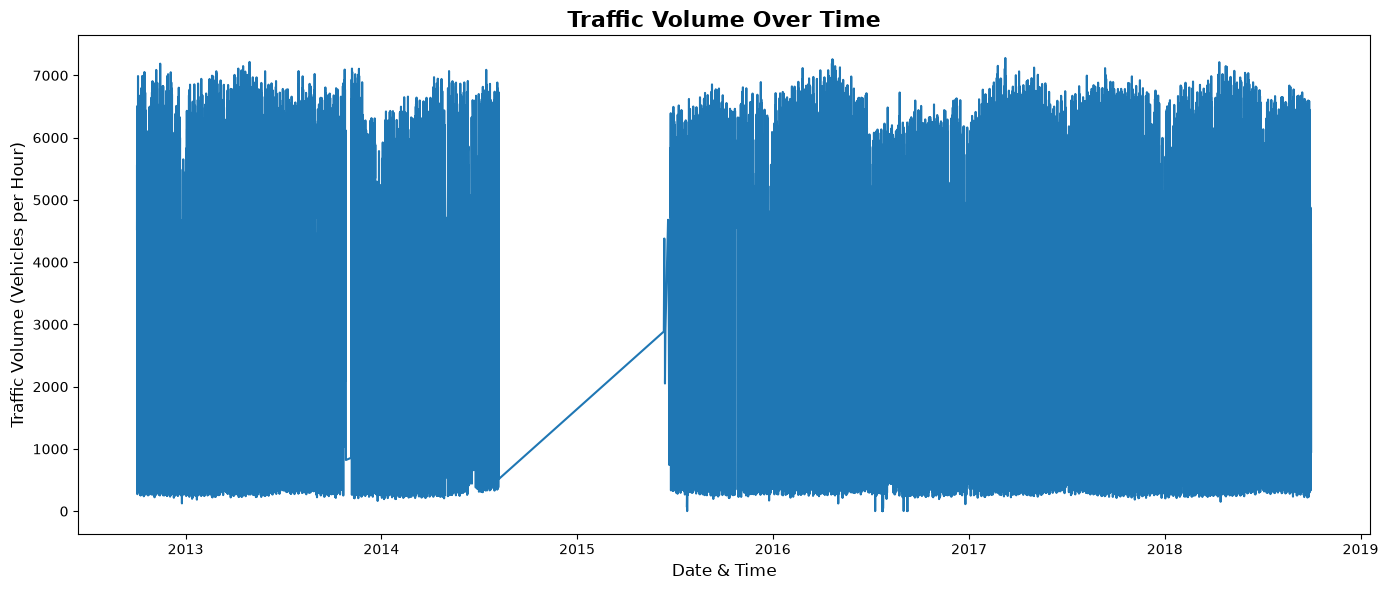

In [22]:
df['date_time'] = pd.to_datetime(df['date_time'], format='%d-%m-%Y %H:%M')

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=df,
    x='date_time',
    y='traffic_volume'
)

plt.title('Traffic Volume Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Date & Time', fontsize=12)
plt.ylabel('Traffic Volume (Vehicles per Hour)', fontsize=12)

plt.tight_layout()
plt.show()

#

#### Numerical Feature Outlier Detection

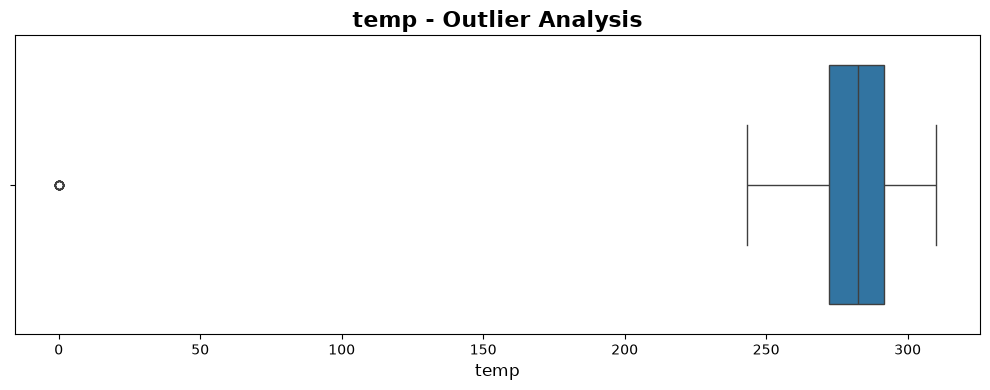

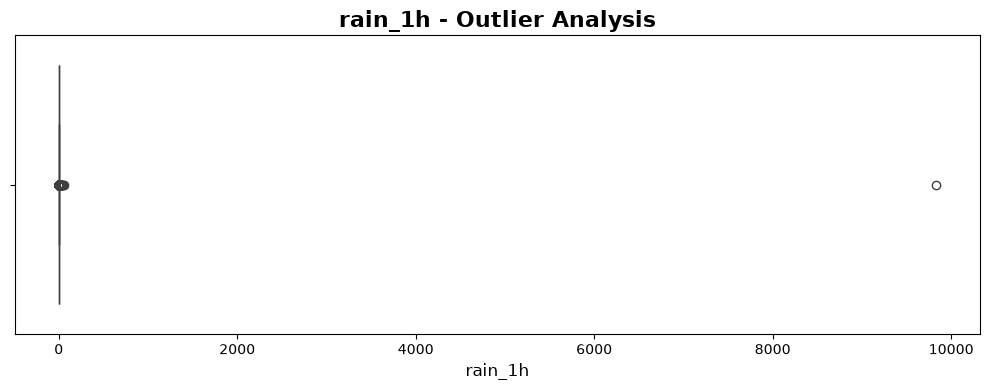

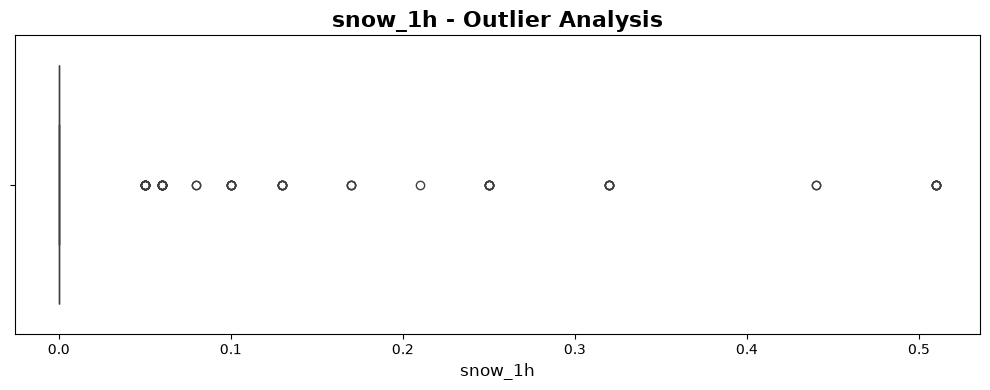

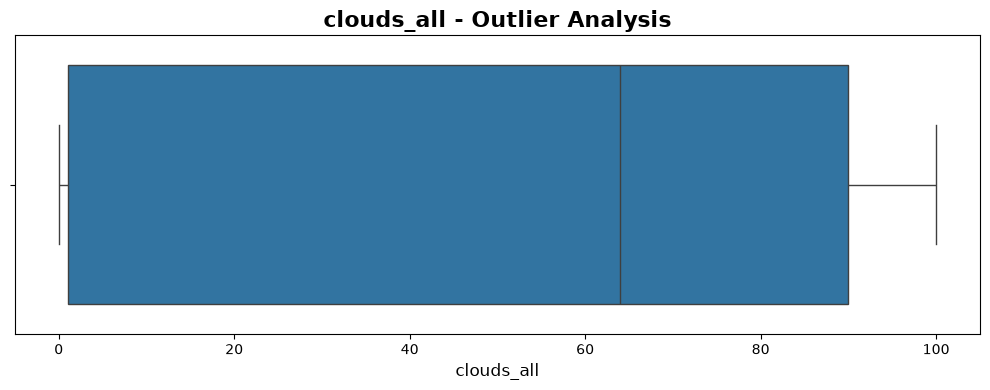

In [23]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('traffic_volume')

for col in num_cols:
    plt.figure(figsize=(10, 4))

    sns.boxplot(
        data=df,
        x=col
    )

    plt.title(f'{col} - Outlier Analysis', fontsize=16, fontweight='bold')
    plt.xlabel(col, fontsize=12)

    plt.tight_layout()
    plt.show()

#### Outlier Treatment Using IQR Capping

In [24]:
cols = ['temp', 'rain_1h', 'snow_1h']

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

#### Outlier Treatment Verification

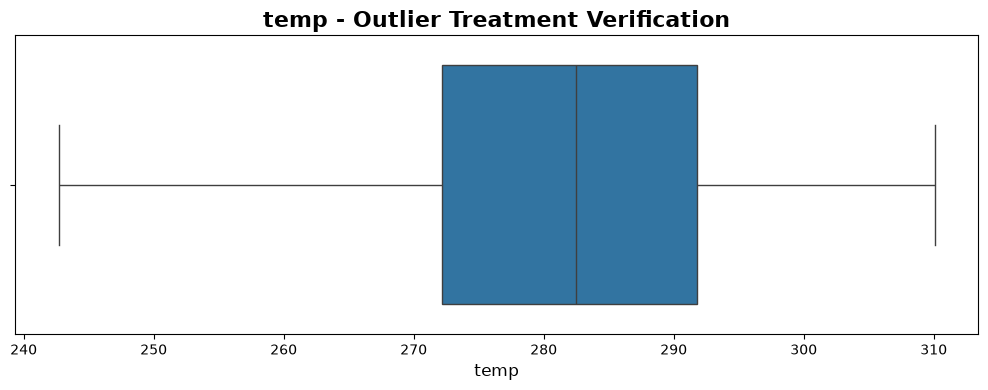

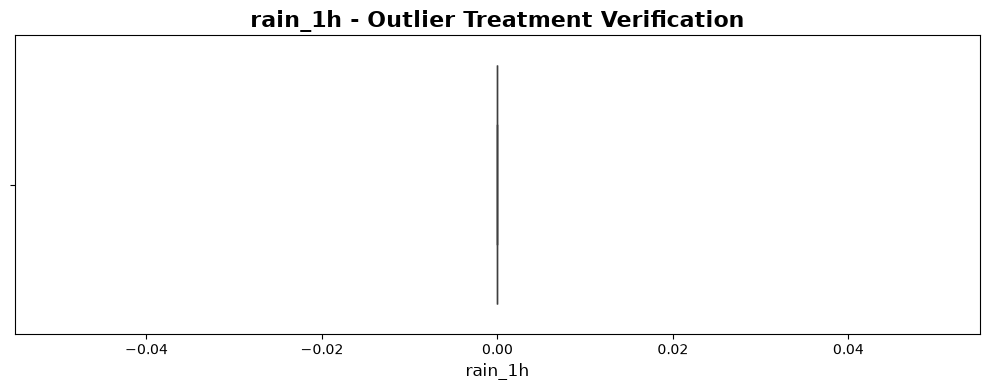

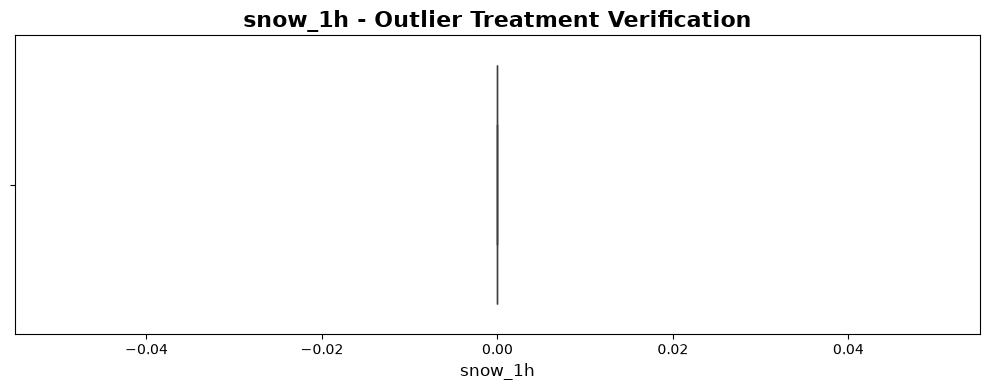

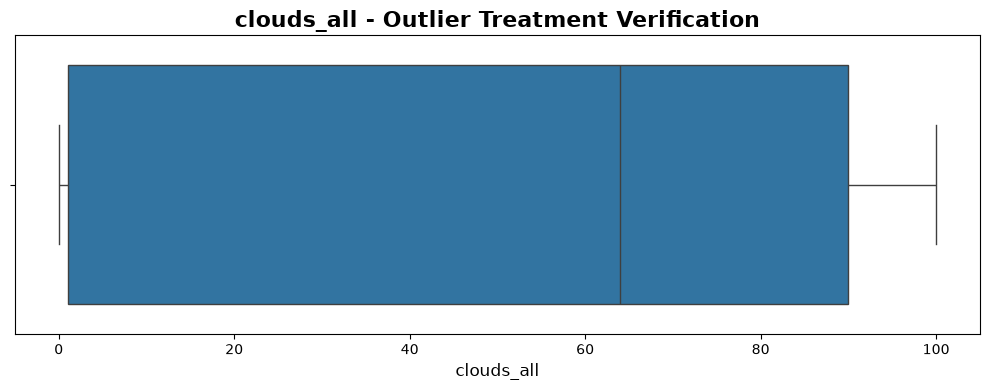

In [25]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('traffic_volume')

for col in num_cols:
    plt.figure(figsize=(10, 4))

    sns.boxplot(
        data=df,
        x=col
    )

    plt.title(f'{col} - Outlier Treatment Verification',
          fontsize=16, fontweight='bold')
    plt.xlabel(col, fontsize=12)

    plt.tight_layout()
    plt.show()

#

#### Date-Time Feature Extraction

In [26]:
df['Hour'] = df['date_time'].dt.hour
df['Day'] = df['date_time'].dt.day
df['Month'] = df['date_time'].dt.month
df['Year'] = df['date_time'].dt.year
df['Day_of_Week'] = df['date_time'].dt.dayofweek
df['Is_Weekend'] = (df['Day_of_Week'] >= 5).astype(int)

#### Original Date-Time Feature Removal

In [27]:
df = df.drop('date_time', axis=1)

###

#### Feature and Target Variable Separation

In [28]:
X = df.drop('traffic_volume', axis=1)

y = df['traffic_volume']

#### Categorical Feature Encoding

In [34]:
# One-Hot Encoding
X = pd.get_dummies(
    X,
    columns=['holiday', 'weather_main'],
    drop_first=True
)

# Frequency Encoding
freq_cols = ['weather_description']
freq_mapping = {}

for col in freq_cols:
    freq_map = X[col].value_counts().to_dict()

    # Save mapping
    freq_mapping[col] = freq_map

    # Apply encoding
    X[col] = X[col].map(freq_map)

#### Boolean Feature Conversion to Numeric Format

In [36]:
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

#### Train-Test Data Splitting

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=.20,
    random_state=42
)

#### Feature Scaling Using StandardScaler

In [41]:
from sklearn.preprocessing import StandardScaler

cols = ['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'Hour',
                      'Day', 'Month', 'Year', 'Day_of_Week', 'weather_description'
]

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[cols] = scaler.fit_transform(X_train[cols])
X_test_scaled[cols] = scaler.transform(X_test[cols])

##

## **Linear Regression**

#### Linear Regression Model Training

In [43]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](32,)","[ 212.06, -0. , -0. ,..., -290.82,-1103.5 , -644.75]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](32,)","['temp','rain_1h','snow_1h',...,'weather_main_Snow','weather_main_Squall', 'weather_main_Thunderstorm']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2478
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,32
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(30)


#### Linear Regression Predictions

In [45]:
y_pred_lr = lr_model.predict(X_test_scaled)

In [52]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

# Adjusted R2
n = X_test_scaled.shape[0]
p = X_test_scaled.shape[1]
adjusted_r2_lr = 1 - ((1 - r2_lr) * (n - 1) / (n - p - 1))

print("MAE:", mae_lr)
print("MSE:", mse_lr)
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)
print("Adjusted R2:", adjusted_r2_lr)

MAE: 1581.2093074746529
MSE: 3228033.7646857947
RMSE: 1796.6729709899337
R2 Score: 0.1925728462410179
Adjusted R2: 0.18988282344869234


##

## **Super Vector Machine**

#### Support Vector Regression (SVR) Model Training

In [57]:
from sklearn.svm import SVR

svr_model = SVR()
svr_model.fit(X_train_scaled, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


#### Support Vector Regression Predictions

In [59]:
y_pred_svr = svr_model.predict(X_test_scaled)

#### Support Vector Regression (SVR) Model Evaluation

In [61]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mae_svr = mean_absolute_error(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mse_svr)
r2_svr = r2_score(y_test, y_pred_svr)

# Adjusted R2
n = X_test_scaled.shape[0]
p = X_test_scaled.shape[1]
adjusted_r2_svr = 1 - ((1 - r2_svr) * (n - 1) / (n - p - 1))

print("MAE:", mae_svr)
print("MSE:", mse_svr)
print("RMSE:", rmse_svr)
print("R2 Score:", r2_svr)
print("Adjusted R2:", adjusted_r2_svr)

MAE: 1562.227750398085
MSE: 3145280.7914086427
RMSE: 1773.4939502035643
R2 Score: 0.21327182355941898
Adjusted R2: 0.21065076144113692


##

## **K-Nearest Neighbors (KNN)**

#### K-Nearest Neighbors (KNN) Model Training

In [67]:
from sklearn.neighbors import KNeighborsRegressor

knn_model = KNeighborsRegressor()
knn_model.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"effective_metric_ effective_metric_: str or callableThe distance metric to use. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'
"effective_metric_params_ effective_metric_params_: dictAdditional keyword arguments for the metric function. For most metricswill be same with `metric_params` parameter, but may also contain the`p` parameter value if the `effective_metric_` attribute is set to'minkowski'.",dict,{}


#### K-Nearest Neighbors (KNN) Predictions

In [69]:
y_pred_knn = knn_model.predict(X_test_scaled)

#### KNN Model Evaluation

In [71]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mae_knn = mean_absolute_error(y_test, y_pred_knn)
mse_knn = mean_squared_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mse_knn)
r2_knn = r2_score(y_test, y_pred_knn)

# Adjusted R2
n = X_test_scaled.shape[0]
p = X_test_scaled.shape[1]
adjusted_r2_knn = 1 - ((1 - r2_knn) * (n - 1) / (n - p - 1))

print("MAE:", mae_knn)
print("MSE:", mse_knn)
print("RMSE:", rmse_knn)
print("R2 Score:", r2_knn)
print("Adjusted R2:", adjusted_r2_knn)

MAE: 730.5900394272671
MSE: 1063123.0272504669
RMSE: 1031.0785747218622
R2 Score: 0.7340813440741596
Adjusted R2: 0.733195409978415


##

## **Decision Tree**

#### Decision Tree Regression Model Training

In [75]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

#### Decision Tree Regression Predictions

In [77]:
y_pred_dt = dt_model.predict(X_test)

#### Decision Tree Regression Model Evaluation

In [80]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

# Adjusted R2
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2_dt = 1 - ((1 - r2_dt) * (n - 1) / (n - p - 1))

print("MAE:", mae_dt)
print("MSE:", mse_dt)
print("RMSE:", rmse_dt)
print("R2 Score:", r2_dt)
print("Adjusted R2:", adjusted_r2_dt)

MAE: 251.13187383274538
MSE: 230164.2335546794
RMSE: 479.75434709305074
R2 Score: 0.9424290867000081
Adjusted R2: 0.9422372835531472


##

## **Random Forest**

#### Random Forest Regression Model Training

In [82]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

#### Random Forest Regression Predictions

In [85]:
y_pred_rf = rf_model.predict(X_test)

#### Random Forest Regression Model Evaluation

In [86]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

# Adjusted R2
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2_rf = 1 - ((1 - r2_rf) * (n - 1) / (n - p - 1))

print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)
print("Adjusted R2:", adjusted_r2_rf)

MAE: 202.2529414816352
MSE: 127681.59509760326
RMSE: 357.32561494749194
R2 Score: 0.9680630394747127
Adjusted R2: 0.9679566383568773


##

## **Gradient Boosting**

#### Gradient Boosting Regression Model Training

In [93]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf

#### Gradient Boosting Regression Predictions

In [94]:
y_pred_gb = gb_model.predict(X_test)

#### Gradient Boosting Regression Model Evaluation

In [96]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mae_gb = mean_absolute_error(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)
r2_gb = r2_score(y_test, y_pred_gb)

# Adjusted R2
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2_gb = 1 - ((1 - r2_gb) * (n - 1) / (n - p - 1))

print("MAE:", mae_gb)
print("MSE:", mse_gb)
print("RMSE:", rmse_gb)
print("R2 Score:", r2_gb)
print("Adjusted R2:", adjusted_r2_gb)

MAE: 353.2431153031139
MSE: 282565.1133071812
RMSE: 531.5685405544436
R2 Score: 0.9293220697735146
Adjusted R2: 0.9290865993136241


##

## **XGBoost**

#### XGBoost Regression Model Training

In [100]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(random_state=42)
xgb_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


#### XGBoost Regression Predictions

In [101]:
y_pred_xgb = xgb_model.predict(X_test)

#### XGBoost Regression Model Evaluation

In [103]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

# Adjusted R2
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2_xgb = 1 - ((1 - r2_xgb) * (n - 1) / (n - p - 1))

print("MAE:", mae_xgb)
print("MSE:", mse_xgb)
print("RMSE:", rmse_xgb)
print("R2 Score:", r2_xgb)
print("Adjusted R2:", adjusted_r2_xgb)

MAE: 204.1997528076172
MSE: 108501.8125
RMSE: 329.39613309812853
R2 Score: 0.9728604555130005
Adjusted R2: 0.9727700374574477


##

## **LightGBM**

#### LightGBM Regression Model Training

In [105]:
from lightgbm import LGBMRegressor

lgbm_model = LGBMRegressor(random_state=42, verbose=-1)
lgbm_model.fit(X_train, y_train)

,random_state,42
,verbose,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0


#### LightGBM Regression Predictions

In [106]:
y_pred_lgbm = lgbm_model.predict(X_test)

#### LightGBM Regression Model Evaluation

In [108]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mae_lgbm = mean_absolute_error(y_test, y_pred_lgbm)
mse_lgbm = mean_squared_error(y_test, y_pred_lgbm)
rmse_lgbm = np.sqrt(mse_lgbm)
r2_lgbm = r2_score(y_test, y_pred_lgbm)

# Adjusted R2
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2_lgbm = 1 - ((1 - r2_lgbm) * (n - 1) / (n - p - 1))

print("MAE:", mae_lgbm)
print("MSE:", mse_lgbm)
print("RMSE:", rmse_lgbm)
print("R2 Score:", r2_lgbm)
print("Adjusted R2:", adjusted_r2_lgbm)

MAE: 214.25199895885365
MSE: 113242.00248307563
RMSE: 336.5144907475392
R2 Score: 0.9716748106072622
Adjusted R2: 0.9715804424593635


##

## **CatBoost**

#### CatBoost Regression Model Training

In [112]:
from catboost import CatBoostRegressor

cb_model = CatBoostRegressor(random_state=42, verbose=0)
cb_model.fit(X_train, y_train)

CatBoostRegressor(loss_function='RMSE', random_state=42, verbose=0)

#### CatBoost Regression Predictions

In [113]:
y_pred_cb = cb_model.predict(X_test)

#### CatBoost Regression Model Evaluation

In [114]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mae_cb = mean_absolute_error(y_test, y_pred_cb)
mse_cb = mean_squared_error(y_test, y_pred_cb)
rmse_cb = np.sqrt(mse_cb)
r2_cb = r2_score(y_test, y_pred_cb)

# Adjusted R2
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2_cb = 1 - ((1 - r2_cb) * (n - 1) / (n - p - 1))

print("MAE:", mae_cb)
print("MSE:", mse_cb)
print("RMSE:", rmse_cb)
print("R2 Score:", r2_cb)
print("Adjusted R2:", adjusted_r2_cb)

MAE: 210.00053829798892
MSE: 114221.14078249625
RMSE: 337.96618289778087
R2 Score: 0.9714298990270656
Adjusted R2: 0.9713347149322051


##

#### **Model Performance Comparison**

In [492]:
comparison_df = pd.DataFrame ({
     "Model": [
         'Linear Regression',
         'SVR',
         'KNN',
         'Decision Tree',
         'Random Forest',
         'Gradient Boosting',
         'Xgboost',
         'lightGBM',
         'CatBoost'
     ],
     "MAE": [
         mae_lr,
         mae_svr,
         mae_knn,
         mae_dt,
         mae_rf,
         mae_gb,
         mae_xgb,
         mae_lgbm,
         mae_cb
     ],
     "MSE": [
         mse_lr,
         mse_svr,
         mse_knn,
         mse_dt,
         mse_rf,
         mse_gb,
         mse_xgb,
         mse_lgbm,
         mse_cb
     ],
     "RMSE": [
         rmse_lr,
         rmse_svr,
         rmse_knn,
         rmse_dt,
         rmse_rf,
         rmse_gb,
         rmse_xgb,
         rmse_lgbm,
         rmse_cb
     ],
     "R2 Score": [
         r2_lr,
         r2_svr,
         r2_knn,
         r2_dt,
         r2_rf,
         r2_gb,
         r2_xgb,
         r2_lgbm,
         r2_cb
     ],
     "Adjusted R2": [
         adjusted_r2_lr,
         adjusted_r2_svr,
         adjusted_r2_knn,
         adjusted_r2_dt,
         adjusted_r2_rf,
         adjusted_r2_gb,
         adjusted_r2_xgb,
         adjusted_r2_lgbm,
         adjusted_r2_cb
     ]
 })

comparison_df = comparison_df.sort_values(by='R2 Score', ascending=False).round(4)
comparison_df

,Model,MAE,MSE,RMSE,R2 Score,Adjusted R2
6,Xgboost,204.1998,1.085018e+05,329.3961,0.9729,0.9728
7,lightGBM,214.2520,1.132420e+05,336.5145,0.9717,0.9716
8,CatBoost,210.0005,1.142211e+05,337.9662,0.9714,0.9713
4,Random Forest,202.2529,1.276816e+05,357.3256,0.9681,0.9680
3,Decision Tree,251.1319,2.301642e+05,479.7543,0.9424,0.9422
5,Gradient Boosting,353.2431,2.825651e+05,531.5685,0.9293,0.9291
2,KNN,730.5900,1.063123e+06,1031.0786,0.7341,0.7332
1,SVR,1562.2278,3.145281e+06,1773.4940,0.2133,0.2107
0,Linear Regression,1581.2093,3.228034e+06,1796.6730,0.1926,0.1899


#### **Regression Model Performance Comparison (R² Score)**

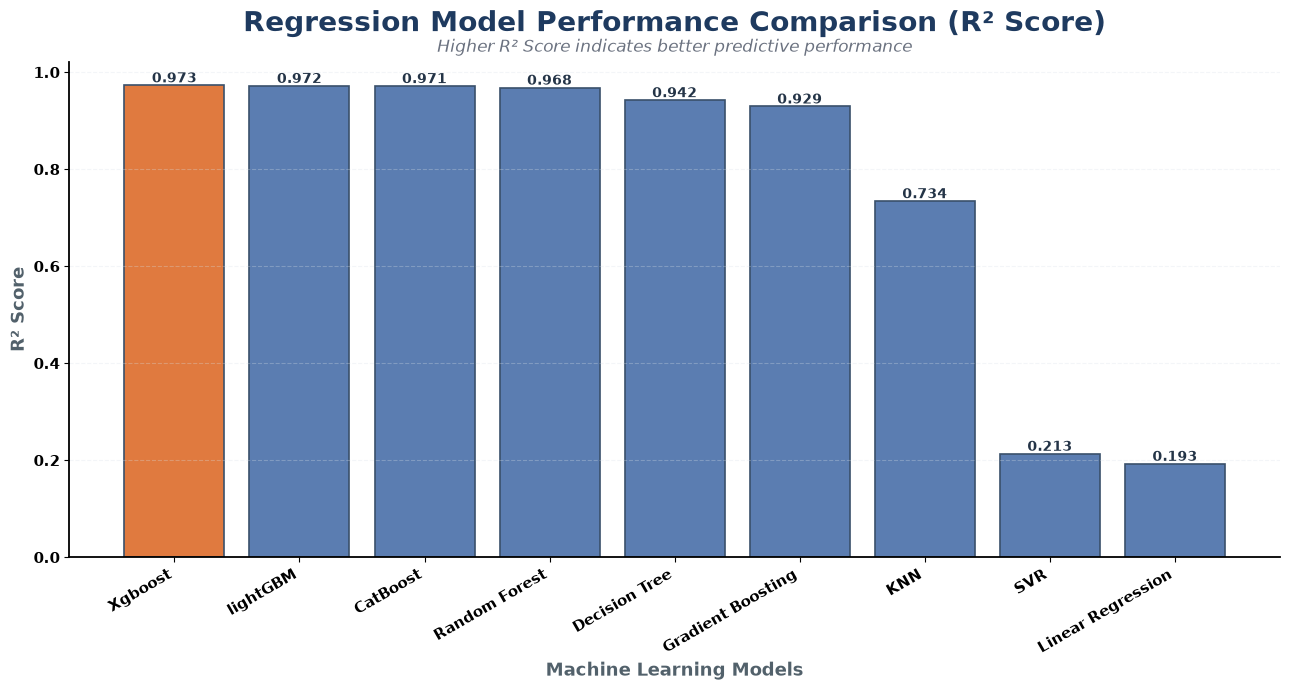

In [179]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(13, 7))

colors = ['#5B7DB1'] * len(comparison_df)

# Hilight best model
best_index = comparison_df['R2 Score'].idxmax()
best_position = comparison_df.index.get_loc(best_index)

colors[best_position] = '#E07A3F'

bars = plt.bar(
    comparison_df["Model"],
    comparison_df["R2 Score"],
    color=colors,
    edgecolor='#3A506B',
    linewidth=1.2
)

plt.title(
    "Regression Model Performance Comparison (R² Score)",
    fontsize=20,
    fontweight='bold',
    color='#1E3A5F',
    pad=22
)

plt.text(
    0.5, 1.02,
    "Higher R² Score indicates better predictive performance",
    transform=plt.gca().transAxes,
    ha='center',
    fontsize=12,
    color='#6B7280',
    style='italic'
)

plt.xlabel(
    "Machine Learning Models",
    fontsize=13,
    fontweight='bold',
    color='#52616B'
)

plt.ylabel(
    "R² Score",
    fontsize=13,
    fontweight='bold',
    color='#52616B'
)

plt.grid(
    axis='y',
    linestyle='--',
    linewidth=0.8,
    alpha=0.3,
    color='#D9E1E8'
)

plt.xticks(
    rotation=30,
    ha='right',
    fontsize=11,
    fontweight='bold'
)

plt.yticks(
    fontsize=11,
    fontweight='bold'
)

# Remove top/Right border
ax = plt.gca()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_linewidth(1.3)
ax.spines['bottom'].set_linewidth(1.3)

# Value Labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.006,
        f"{height:.3f}",
        ha='center',
        fontsize=10,
        fontweight='bold',
        color='#243447'
    )

plt.tight_layout()
plt.show()

##

#### **XGBoost Hyperparameter Tuning Using RandomizedSearchCV**

In [184]:
from sklearn.model_selection import RandomizedSearchCV

xgb = XGBRegressor(
    random_state=42,
    objective='reg:squarederror'
)

param_dist = {
    'n_estimators':[100, 200, 300, 500, 700],
    'learning_rate':[0.001, 0.01, 0.05, 0.1],
    'max_depth':[1, 3, 5, 7, 10],
    'min_child_weight':[1, 2, 4, 6, 8],
    'subsample':[0.60, 0.70, 0.80, 0.90, 1.0],
    'colsample_bytree':[0.50, 0.60, 0.80, 0.90, 1.0],
    'gamma':[0.1, 0.3, 0.5, 0.7, 1],
    'reg_alpha': [0.5, 1.5, 3, 4, 5, 7],
    'reg_lambda':[0.5, 2, 4, 6, 8, 10, 15]
}

random_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    cv=5,
    n_iter=20,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

random_search_xgb.fit(X_train, y_train)

print("Best Parameters:", random_search_xgb.best_params_)
print("Best Score:", random_search_xgb.best_score_)

Best Parameters: {'subsample': 0.7, 'reg_lambda': 4, 'reg_alpha': 1.5, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 10, 'learning_rate': 0.1, 'gamma': 1, 'colsample_bytree': 0.8}
Best Score: 0.9788926005363464


#### **Tuned XGBoost Regression Model Training**

In [185]:
xgb_tuned = XGBRegressor(
    objective='reg:squarederror',
    subsample=0.7,
    reg_lambda=4,
    reg_alpha=1.5,
    n_estimators=200,
    min_child_weight=1,
    max_depth=10,
    learning_rate=0.1,
    gamma=1,
    colsample_bytree=0.8,
    random_state=42
)

xgb_tuned.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


#### Tuned XGBoost Regression Predictions

In [186]:
y_pred_xgb_tuned = xgb_tuned.predict(X_test)

#### Tuned XGBoost Regression Model Evaluation

In [188]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mae_xgb_tuned = mean_absolute_error(y_test, y_pred_xgb_tuned)
mse_xgb_tuned = mean_squared_error(y_test, y_pred_xgb_tuned)
rmse_xgb_tuned = np.sqrt(mse_xgb_tuned)
r2_xgb_tuned = r2_score(y_test, y_pred_xgb_tuned)

# Adjusted R2
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2_xgb_tuned = 1 - ((1 - r2_xgb_tuned) * (n - 1) / (n - p - 1))

print("MAE:", mae_xgb_tuned)
print("MSE:", mse_xgb_tuned)
print("RMSE:", rmse_xgb_tuned)
print("R2 Score:", r2_xgb_tuned)
print("Adjusted R2:", adjusted_r2_xgb_tuned)

MAE: 167.61351013183594
MSE: 72986.3125
RMSE: 270.15979067951616
R2 Score: 0.9817439317703247
Adjusted R2: 0.9816831098876231


##

#### **LightGBM Hyperparameter Tuning Using RandomizedSearchCV**

In [191]:
from sklearn.model_selection import RandomizedSearchCV

lgbm = LGBMRegressor(
    random_state=42,
    verbosity=-1
)

param_dist = {
    'n_estimators':[100, 200, 300, 500, 700, 1000],
    'learning_rate':[0.001, 0.003, 0.005, 0.01, 0.05, 0.1],
    'num_leaves':[15, 31, 50, 70, 100, 150],
    'max_depth':[-1, 3, 5, 7, 10, 15],
    'min_child_samples':[5, 10, 15, 20, 30, 50, 80],
    'subsample': [0.5, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree':[0.6, 0.7, 0.8, 0.9, 1.0],
    'reg_alpha':[0, 0.01, 0.1, 0.5, 1, 5],
    'reg_lambda':[0, 0.01, 0.1, 0.5, 1, 5, 10],
    'min_split_gain':[0, 0.01, 0.1, 0.5, 1]
}

random_search_lgbm = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

random_search_lgbm.fit(X_train, y_train)

print("Best Parameters:", random_search_lgbm.best_params_)
print("Best Score:", random_search_lgbm.best_score_)

Best Parameters: {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0.01, 'num_leaves': 70, 'n_estimators': 1000, 'min_split_gain': 0.1, 'min_child_samples': 5, 'max_depth': 10, 'learning_rate': 0.1, 'colsample_bytree': 0.7}
Best Score: 0.9801681383691407


#### **Tuned LightGBM Regression Model Training**

In [193]:
lgbm_tuned = LGBMRegressor(
    subsample=0.8,
    reg_lambda=1,
    reg_alpha=0.01,
    num_leaves=70,
    n_estimators=1000,
    min_split_gain=0.1,
    min_child_samples=5,
    max_depth=10,
    learning_rate=0.1,
    colsample_bytree=0.7,
    random_state=42
)

lgbm_tuned.fit(X_train, y_train)

,num_leaves,70
,max_depth,10
,n_estimators,1000
,min_split_gain,0.1
,min_child_samples,5
,subsample,0.8
,colsample_bytree,0.7
,reg_alpha,0.01
,reg_lambda,1
,random_state,42
,boosting_type,'gbdt'


#### Tuned LightGBM Regression Predictions

In [195]:
y_pred_lgbm_tuned = lgbm_tuned.predict(X_test)

#### Tuned LightGBM Regression Model Evaluation

In [197]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mae_lgbm_tuned = mean_absolute_error(y_test, y_pred_lgbm_tuned)
mse_lgbm_tuned = mean_squared_error(y_test, y_pred_lgbm_tuned)
rmse_lgbm_tuned = np.sqrt(mse_lgbm_tuned)
r2_lgbm_tuned = r2_score(y_test, y_pred_lgbm_tuned)

# Adjusted R2
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2_lgbm_tuned = 1 - ((1 - r2_lgbm_tuned) * (n - 1) / (n - p - 1))

print("MAE:", mae_lgbm_tuned)
print("MSE:", mse_lgbm_tuned)
print("RMSE:", rmse_lgbm_tuned)
print("R2 Score:", r2_lgbm_tuned)
print("Adjusted R2:", adjusted_r2_lgbm_tuned)

MAE: 167.2657754785291
MSE: 71839.53836765545
RMSE: 268.0289879241711
R2 Score: 0.9820307970052472
Adjusted R2: 0.9819709308422246


#

#### **CatBoost Hyperparameter Tuning Using RandomizedSearchCV**

In [206]:
from sklearn.model_selection import RandomizedSearchCV

cb = CatBoostRegressor(
    random_state=42,
    verbose=0
)

param_dist = {
    'iterations':[100, 200, 300, 500, 700],
    'learning_rate':[0.001, 0.003, 0.005, 0.01, 0.05, 0.1],
    'depth':[2, 3, 5, 7, 10],
    'l2_leaf_reg':[3, 5, 10, 15, 20, 30],
    'loss_function':["MAE", "RMSE"],
    'random_strength':[0, 0.3, 0.5, 1, 3, 5, 10],
    'bagging_temperature':[0, 0.5, 1, 3, 5, 10],
    'subsample':[0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bylevel':[0.6, 0.7, 0.8, 0.9, 1.0],
    'border_count':[32, 64, 128, 254],
    'min_data_in_leaf':[3, 4, 7, 10, 15, 20, 30, 50, 80]
}

random_search_cb = RandomizedSearchCV(
    estimator=cb,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

random_search_cb.fit(X_train, y_train)

print("Best Parameters:", random_search_cb.best_params_)
print("Best Score:", random_search_cb.best_score_)

Best Parameters: {'subsample': 0.7, 'random_strength': 0.5, 'min_data_in_leaf': 50, 'loss_function': 'RMSE', 'learning_rate': 0.05, 'l2_leaf_reg': 5, 'iterations': 700, 'depth': 7, 'colsample_bylevel': 0.7, 'border_count': 254, 'bagging_temperature': 10}
Best Score: 0.9665154200593534


#### **Tuned CatBoost Regression Model Training**

In [215]:
cb_tuned = CatBoostRegressor(
    subsample=0.7,
    random_strength=0.5,
    min_data_in_leaf=50,
    loss_function='RMSE',
    learning_rate=0.05,
    l2_leaf_reg=5,
    iterations=700,
    depth=7,
    colsample_bylevel=0.7,
    border_count=254,
    bagging_temperature=10,
    verbose=0
)

cb_tuned.fit(X_train, y_train)

CatBoostRegressor(bagging_temperature=10, border_count=254, colsample_bylevel=0.7, depth=7, iterations=700, l2_leaf_reg=5, learning_rate=0.05, loss_function='RMSE', min_data_in_leaf=50, random_strength=0.5, subsample=0.7, verbose=0)

#### Tuned CatBoost Regression Predictions

In [216]:
y_pred_cb_tuned = cb_tuned.predict(X_test)

#### Tuned CatBoost Regression Model Evaluation

In [217]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mae_cb_tuned = mean_absolute_error(y_test, y_pred_cb_tuned)
mse_cb_tuned = mean_squared_error(y_test, y_pred_cb_tuned)
rmse_cb_tuned = np.sqrt(mse_cb_tuned)
r2_cb_tuned = r2_score(y_test, y_pred_cb_tuned)

# Adjusted R2
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2_cb_tuned = 1 - ((1 - r2_cb_tuned) * (n - 1) / (n - p - 1))

print("MAE:", mae_cb_tuned)
print("MSE:", mse_cb_tuned)
print("RMSE:", rmse_cb_tuned)
print("R2 Score:", r2_cb_tuned)
print("Adjusted R2:", adjusted_r2_cb_tuned)

MAE: 213.67164451890594
MSE: 119193.53361283765
RMSE: 345.24416521186515
R2 Score: 0.9701861558437396
Adjusted R2: 0.9700868280964204


#

#### **Random Forest Hyperparameter Tuning Using RandomizedSearchCV**

In [213]:
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestRegressor(random_state=42)

param_dist = {
    'n_estimators':[100, 200, 300, 500, 700],
    'max_depth':[2, 3, 5, 7, 10, 15],
    'min_samples_split':[2, 5, 7, 10, 15],
    'min_samples_leaf':[1, 3, 5, 8, 10],
    'max_features':['sqrt', 'log2', None], 
    'max_samples':[0.6, 0.7, 0.8, 0.9, 1.0],
    'bootstrap':[True],
    'criterion':['squared_error', 'absolute_error'],
    'ccp_alpha':[0.001, 0.005, 0.01, 0.05, 0.1],
    'min_impurity_decrease':[0, 0.01, 0.05, 0.1, 0.5, 1]
}

random_search_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

random_search_rf.fit(X_train, y_train)

print("Best Parameters:", random_search_rf.best_params_)
print("Best Score:", random_search_rf.best_score_)

Best Parameters: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 3, 'min_impurity_decrease': 0.05, 'max_samples': 0.6, 'max_features': None, 'max_depth': 15, 'criterion': 'squared_error', 'ccp_alpha': 0.005, 'bootstrap': True}
Best Score: 0.9558487043753349


#### **Tuned Random Forest Regression Model Training**

In [219]:
rf_tuned = RandomForestRegressor(
    n_estimators=200,
    min_samples_split=10,
    min_samples_leaf=3,
    min_impurity_decrease=0.05,
    max_samples=0.6,
    max_features=None,
    max_depth=15,
    criterion='squared_error',
    ccp_alpha=0.005,
    bootstrap=True,
    random_state=42
)

rf_tuned.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.05
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"ccp_alpha ccp_alpha: non-negative float, default=0.0Complexity parameter used for Minimal Cost-Complexity Pruning. Thesubtree with the largest cost complexity that is smaller than``ccp_alpha`` will be chosen. By default, no pruning is performed. See:ref:`minimal_cost_complexity_pruning` for details. See:ref:`sphx_glr_auto_examples_tree_plot_cost_complexity_pruning.py`for an example of such pruning... versionadded:: 0.22",0.005
,"max_samples max_samples: int or float, default=NoneIf bootstrap is True, the number of samples to draw from Xto train each base estimator.- If None (default), then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.-

#### Tuned Random Forest Regression Predictions

In [221]:
y_pred_rf_tuned = rf_tuned.predict(X_test)

#### Tuned Random Forest Regression Model Evaluation

In [222]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mae_rf_tuned = mean_absolute_error(y_test, y_pred_rf_tuned)
mse_rf_tuned = mean_squared_error(y_test, y_pred_rf_tuned)
rmse_rf_tuned = np.sqrt(mse_rf_tuned)
r2_rf_tuned = r2_score(y_test, y_pred_rf_tuned)

# Adjusted R2
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2_rf_tuned = 1 - ((1 - r2_rf_tuned) * (n - 1) / (n - p - 1))

print("MAE:", mae_rf_tuned)
print("MSE:", mse_rf_tuned)
print("RMSE:", rmse_rf_tuned)
print("R2 Score:", r2_rf_tuned)
print("Adjusted R2:", adjusted_r2_rf_tuned)

MAE: 224.8820151096756
MSE: 153499.33638967882
RMSE: 391.789913588493
R2 Score: 0.9616052552978563
Adjusted R2: 0.9614773394383593


##

#### **Baseline vs Tuned Regression Model Performance Comparison**

In [225]:
tuned_comparison_df = pd.DataFrame({
    "Model": [
        'CatBoost (Baseline)',
        'CatBoost (Tuned)',
        'LightGBM (Baseline)',
        'LightGBM (Tuned)',
        'XGBoost (Baseline)',
        'XGBoost (Tuned)',
        'Random Forest (Baseline)',
        'Random Forest (Tuned)'
    ],
    "MAE": [
        mae_cb,
        mae_cb_tuned,
        mae_lgbm,
        mae_lgbm_tuned,
        mae_xgb,
        mae_xgb_tuned,
        mae_rf,
        mae_rf_tuned
    ],
    "MSE": [
        mse_cb,
        mse_cb_tuned,
        mse_lgbm,
        mse_lgbm_tuned,
        mse_xgb,
        mse_xgb_tuned,
        mse_rf,
        mse_rf_tuned
    ],
    "RMSE": [
        rmse_cb,
        rmse_cb_tuned,
        rmse_lgbm,
        rmse_lgbm_tuned,
        rmse_xgb,
        rmse_xgb_tuned,
        rmse_rf,
        rmse_rf_tuned
    ],
    "R2 Score": [
        r2_cb,
        r2_cb_tuned,
        r2_lgbm,
        r2_lgbm_tuned,
        r2_xgb,
        r2_xgb_tuned,
        r2_rf,
        r2_rf_tuned
    ],
    "Adjusted R2": [
        adjusted_r2_cb,
        adjusted_r2_cb_tuned,
        adjusted_r2_lgbm,
        adjusted_r2_lgbm_tuned,
        adjusted_r2_xgb,
        adjusted_r2_xgb_tuned,
        adjusted_r2_rf,
        adjusted_r2_rf_tuned
    ]
})

tuned_comparison_df = tuned_comparison_df.sort_values(by="R2 Score", ascending=False).round(4)
tuned_comparison_df

,Model,MAE,MSE,RMSE,R2 Score,Adjusted R2
3,LightGBM (Tuned),167.2658,71839.5384,268.0290,0.9820,0.9820
5,XGBoost (Tuned),167.6135,72986.3125,270.1598,0.9817,0.9817
4,XGBoost (Baseline),204.1998,108501.8125,329.3961,0.9729,0.9728
2,LightGBM (Baseline),214.2520,113242.0025,336.5145,0.9717,0.9716
0,CatBoost (Baseline),210.0005,114221.1408,337.9662,0.9714,0.9713
1,CatBoost (Tuned),213.6716,119193.5336,345.2442,0.9702,0.9701
6,Random Forest (Baseline),202.2529,127681.5951,357.3256,0.9681,0.9680
7,Random Forest (Tuned),224.8820,153499.3364,391.7899,0.9616,0.9615


#### **Original vs Tuned Regression Model Performance Comparison (R² Score)**

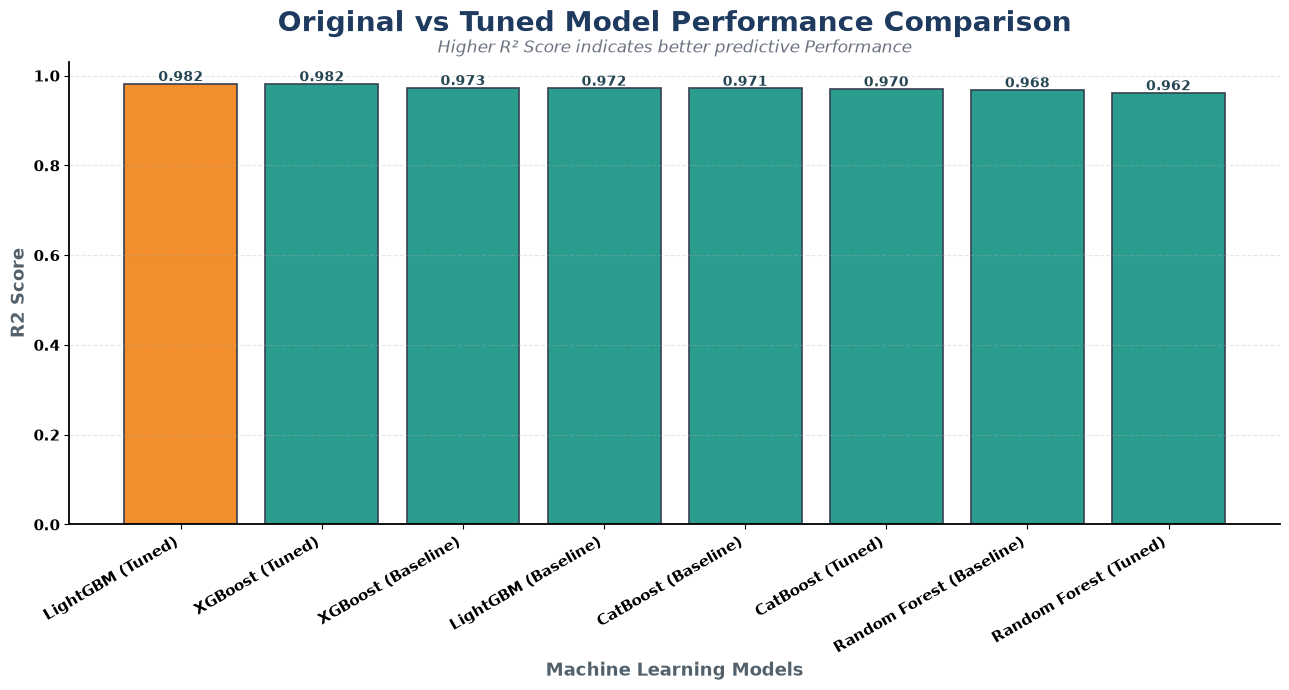

In [265]:
import matplotlib.pyplot as plt

plt.figure(figsize=(13, 7))

colors = ['#2A9D8F'] * len(tuned_comparison_df)

# Highlight best model
best_index = tuned_comparison_df['R2 Score'].idxmax()
best_position = tuned_comparison_df.index.get_loc(best_index)
colors[best_position] = '#F28E2B'

bars = plt.bar(
    tuned_comparison_df['Model'],
    tuned_comparison_df['R2 Score'],
    color=colors,
    edgecolor='#374151',
    linewidth=1.2
)

plt.title(
    "Original vs Tuned Model Performance Comparison",
    fontsize=20,
    fontweight='bold',
    color='#1E3A5F',
    pad=22
)

plt.text(
    0.5, 1.02,
    "Higher R² Score indicates better predictive Performance",
    transform=plt.gca().transAxes,
    ha='center',
    fontsize=12,
    color='#6B7280',
    style='italic'
)

plt.xlabel(
    "Machine Learning Models",
    fontsize=13,
    fontweight='bold',
    color='#52616B'
)

plt.ylabel(
    "R2 Score",
    fontsize=13,
    fontweight='bold',
    color='#52616B'
)

plt.grid(
    axis = 'y',
    linestyle='--',
    linewidth=0.8,
    alpha=0.3
)

plt.xticks(
    rotation=30,
    ha='right',
    fontsize=11,
    fontweight='bold'
)

plt.yticks(
    fontsize=11,
    fontweight='bold'
)

# Remove top/right border
ax = plt.gca()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_linewidth(1.3)
ax.spines['bottom'].set_linewidth(1.3)

# Value Labels
for bar in bars:
    height = bar.get_height()
    plt.text(
       bar.get_x() + bar.get_width() / 2,
       height + 0.006,
       f"{height:.3f}",
       ha='center',
       fontsize=10,
        fontweight='bold',
        color='#264653'
    )

plt.tight_layout()
plt.show()

#

### **Final Selected Model Performance - Tuned LightGBM**

In [271]:
final_model_df = pd.DataFrame({
    "Model": ['Tuned LightGBM'],
    "MAE": [mae_lgbm_tuned],
    "MSE": [mse_lgbm_tuned],
    "RMSE": [rmse_lgbm_tuned],
    "R2 Score": [r2_lgbm_tuned],
    "Adjusted R2": [adjusted_r2_lgbm_tuned]
})

final_model_df = final_model_df.round(4)
final_model_df

,Model,MAE,MSE,RMSE,R2 Score,Adjusted R2
0,Tuned LightGBM,167.2658,71839.5384,268.029,0.982,0.982


###

#### **Final Model Generalization Performance**

In [277]:
print("Train Score:", lgbm_tuned.score(X_train, y_train))
print("Test Score:", lgbm_tuned.score(X_test, y_test))

Train Score: 0.994280230115973
Test Score: 0.9820307970052472


#### **Residual Distribution Analysis of Tuned LightGBM**

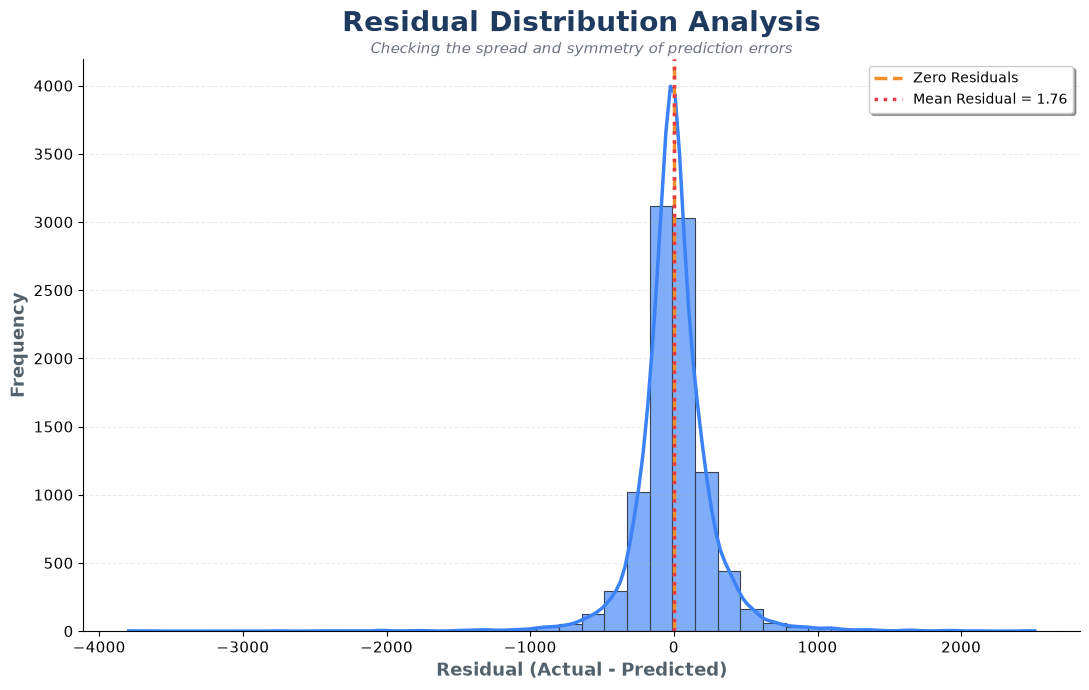

In [323]:
residuals = y_test - y_pred_lgbm_tuned

plt.figure(figsize=(11, 7))

sns.histplot(
    residuals,
    kde=True,
    bins=40,
    edgecolor='#374151',
    linewidth=0.8,
    alpha=0.65,
    color='#3B82F6',
    line_kws={"linewidth":2.5}
)

plt.axvline(
    0,
    color='#F28E2B',
    linestyle='--',
    linewidth=2.5,
    label='Zero Residuals'
)

plt.axvline(
    residuals.mean(),
    color='#E63946',
    linestyle=':',
    linewidth=2.5,
    label=f"Mean Residual = {residuals.mean():.2f}"
)

plt.title(
    "Residual Distribution Analysis",
    fontsize=20,
    fontweight='bold',
    color='#1E3A5F',
    pad=20
)

plt.text(
    0.5, 1.01,
    "Checking the spread and symmetry of prediction errors",
    transform=plt.gca().transAxes,
    ha='center',
    fontsize=11,
    color='#6B7280',
    style='italic'
)

plt.xlabel(
    "Residual (Actual - Predicted)",
    fontsize=13,
    fontweight='bold',
    color='#52616B'
)

plt.ylabel(
    "Frequency",
    fontsize=13,
    fontweight='bold',
    color='#52616B'
)

plt.grid(
    axis='y',
    linestyle='--',
    linewidth=0.8,
    alpha=0.25
)

plt.legend(
    loc='upper right',
    frameon=True,
    fancybox=True,
    shadow=True
)

ax = plt.gca()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xticks(
    fontsize=11
)

plt.yticks(
    fontsize=11
)

plt.tight_layout()
plt.show()

#### **Predicted Values vs Residuals Analysis**

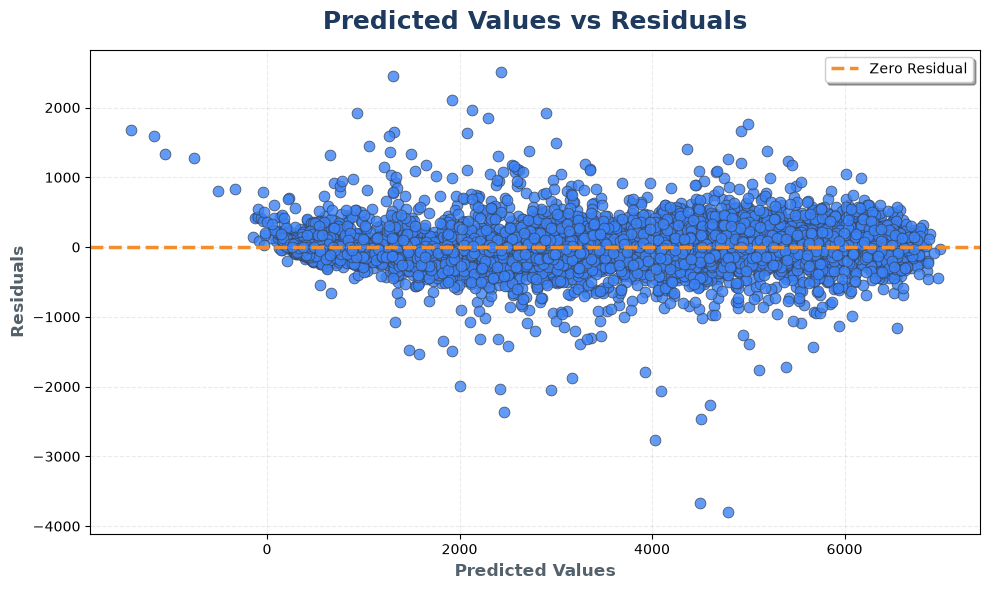

In [353]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=y_pred_lgbm_tuned,
    y=residuals,
    color='#3B82F6',
    edgecolor='#374151',
    alpha=0.8,
    s=60
)

plt.axhline(
    y=0,
    linestyle="--",
    color='#F28E2B',
    linewidth=2.5,
    label="Zero Residual"
)

plt.title(
    "Predicted Values vs Residuals",
    fontsize=18,
    fontweight='bold',
    color='#1E3A5F',
    pad=15
)

plt.xlabel(
    "Predicted Values",
    fontsize=12,
    fontweight='bold',
    color='#52616B'
)

plt.ylabel(
    "Residuals",
    fontsize=12,
    fontweight='bold',
    color='#52616B'
)

plt.grid(
    axis='both',
    linestyle='--',
    alpha=0.25
)

plt.legend(
    frameon=True,
    fancybox=True,
    shadow=True
)

plt.tight_layout()
plt.show()

#### **Actual vs Predicted Values Analysis**

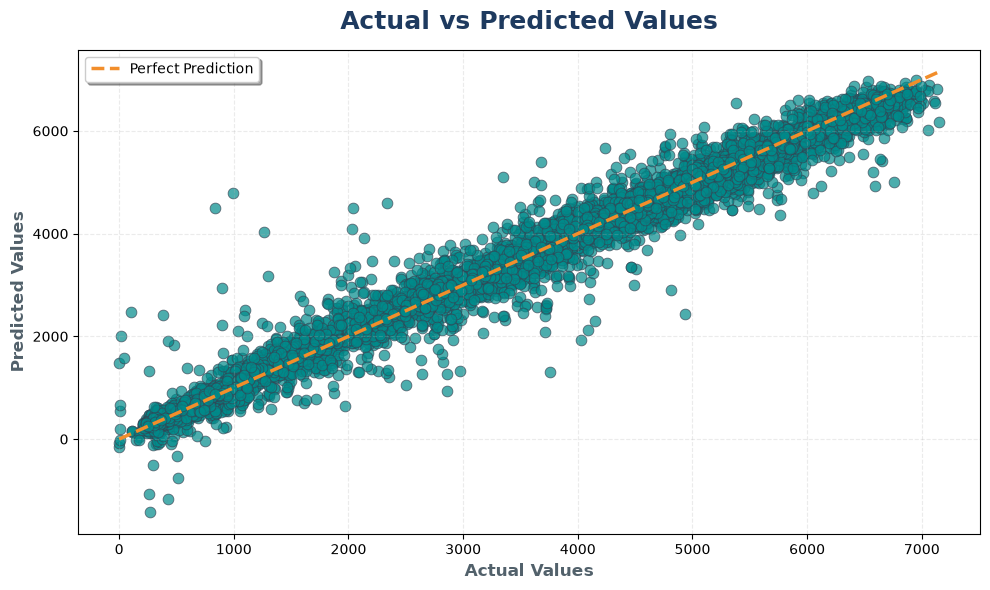

In [370]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=y_test,
    y=y_pred_lgbm_tuned,
    color='#008B8B',
    edgecolor='#374151',
    alpha=0.7,
    s=60
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='#F28E2B',
    linestyle="--",
    linewidth=2.5,
    label="Perfect Prediction"
)

plt.title(
    "Actual vs Predicted Values",
    fontsize=18,
    fontweight='bold',
    color='#1E3A5F',
    pad=15
)

plt.xlabel(
    "Actual Values",
    fontsize=12,
    fontweight='bold',
    color='#52616B'
)

plt.ylabel(
    "Predicted Values",
    fontsize=12,
    fontweight='bold',
    color='#52616B'
)

plt.grid(
    axis='both',
    linestyle='--',
    alpha=0.25
)

plt.legend(
    frameon=True,
    fancybox=True,
    shadow=True
)

plt.tight_layout()
plt.show()

####

### **Top 10 Feature Importance - Tuned LightGBM**

In [437]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": lgbm_tuned.feature_importances_
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False).head(10)
feature_importance

,Feature,Importance
0,temp,14929
5,Hour,11248
6,Day,11075
9,Day_of_Week,7054
7,Month,6817
8,Year,5619
3,clouds_all,4821
4,weather_description,4126
22,weather_main_Clouds,838
10,Is_Weekend,759


#### **Top 10 Feature Importance Analysis**

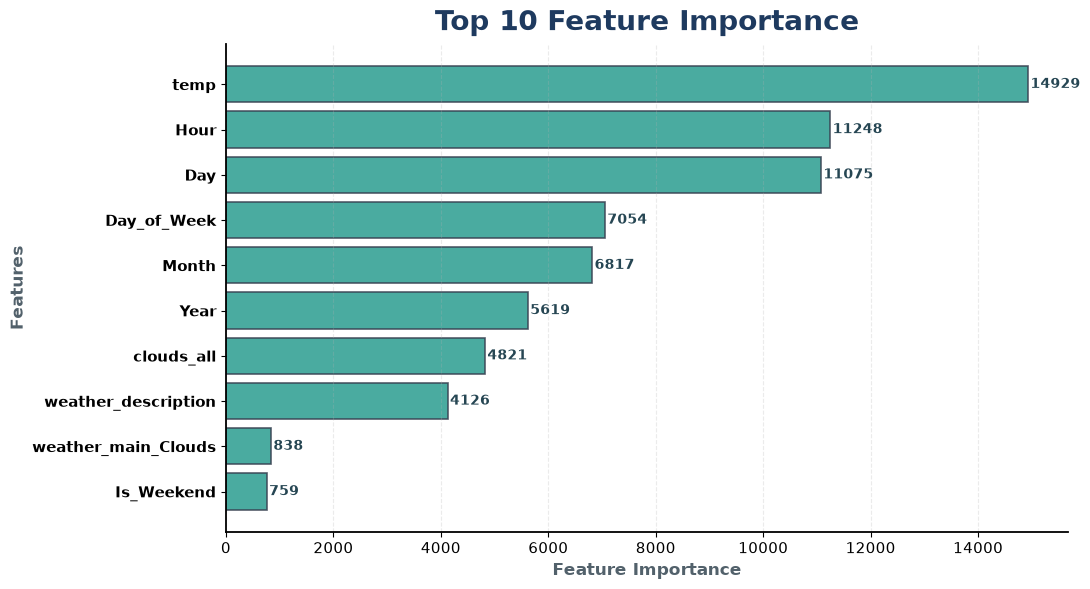

In [438]:
top_10 = feature_importance.sort_values(by='Importance', ascending=True)

plt.figure(figsize=(11, 6))

bars = plt.barh(
    top_10["Feature"],
    top_10["Importance"],
    color='#2A9D8F',
    edgecolor='#374151',
    linewidth=1.2,
    alpha=0.85
)

plt.title(
    "Top 10 Feature Importance",
    fontsize=20,
    fontweight='bold',
    color='#1E3A5F',
    pad=10
)

plt.xlabel(
    "Feature Importance",
    fontsize=12,
    fontweight='bold',
    color='#52616B'
)

plt.ylabel(
    "Features",
    fontsize=12,
    fontweight='bold',
    color='#52616B'
)

plt.grid(
    axis='x',
    linestyle='--',
    linewidth=0.8,
    alpha=0.25
)

plt.xticks(fontsize=11)

plt.yticks(fontsize=11, fontweight='bold')

# Remove border
ax = plt.gca()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_linewidth(1.3)
ax.spines['bottom'].set_linewidth(1.3)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + (top_10["Importance"].max() * 0.003),
        bar.get_y() + bar.get_height() / 2,
        f"{width:.0f}",
        va='center',
        ha='left',
        color='#264653',
        fontweight='bold',
        fontsize=10
    )

plt.tight_layout()
plt.show()

#### **SHAP Feature Impact Analysis**

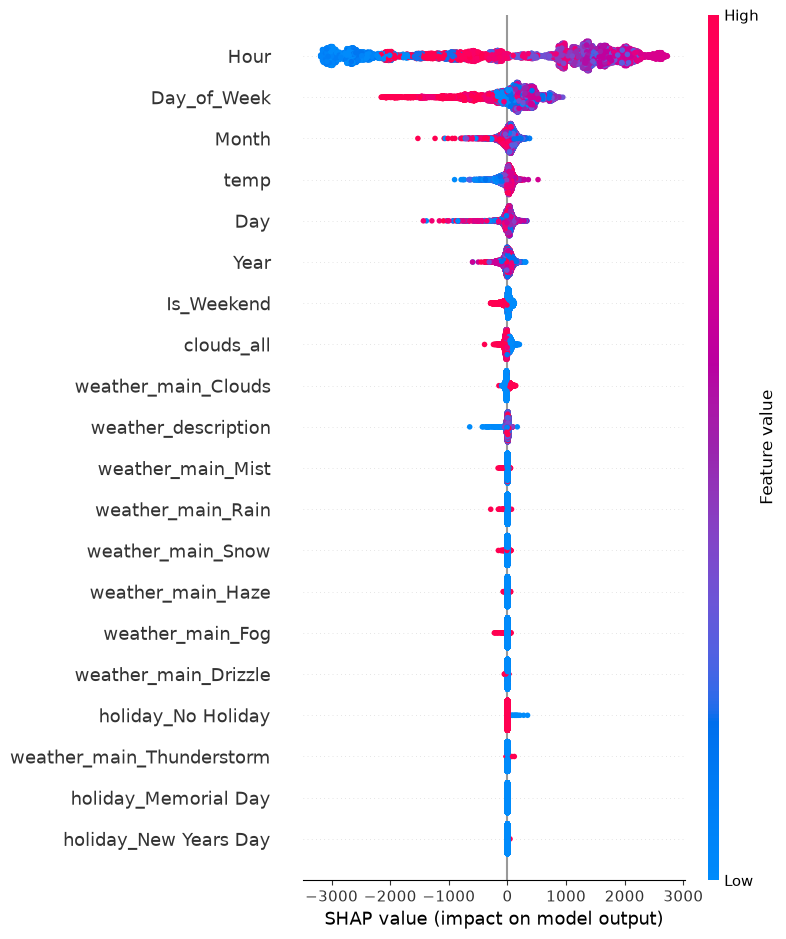

In [440]:
import shap

explainer = shap.TreeExplainer(lgbm_tuned)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

#### **SHAP Dependence Analysis — Hour Feature**

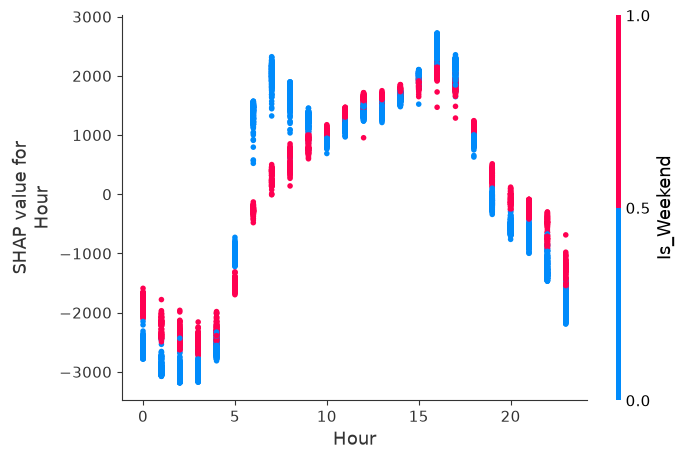

In [449]:
shap.dependence_plot(
    "Hour",
    shap_values,
    X_test
)

#### **Top 10 Permutation Feature Importance Analysis**

In [444]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    lgbm_tuned,
    X_test,
    y_test,
    scoring='r2',
    n_repeats=10,
    random_state=42
)

permutation_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': perm_result.importances_mean
})

permutation_importance = permutation_importance.sort_values(
    by='Importance',
    ascending=False
).head(10)

permutation_importance

,Feature,Importance
5,Hour,1.775754
9,Day_of_Week,0.252822
7,Month,0.034348
6,Day,0.033661
0,temp,0.020514
8,Year,0.013712
10,Is_Weekend,0.005506
3,clouds_all,0.003986
4,weather_description,0.001792
22,weather_main_Clouds,0.001545


#### **Top 10 Permutation Feature Importance Analysis**

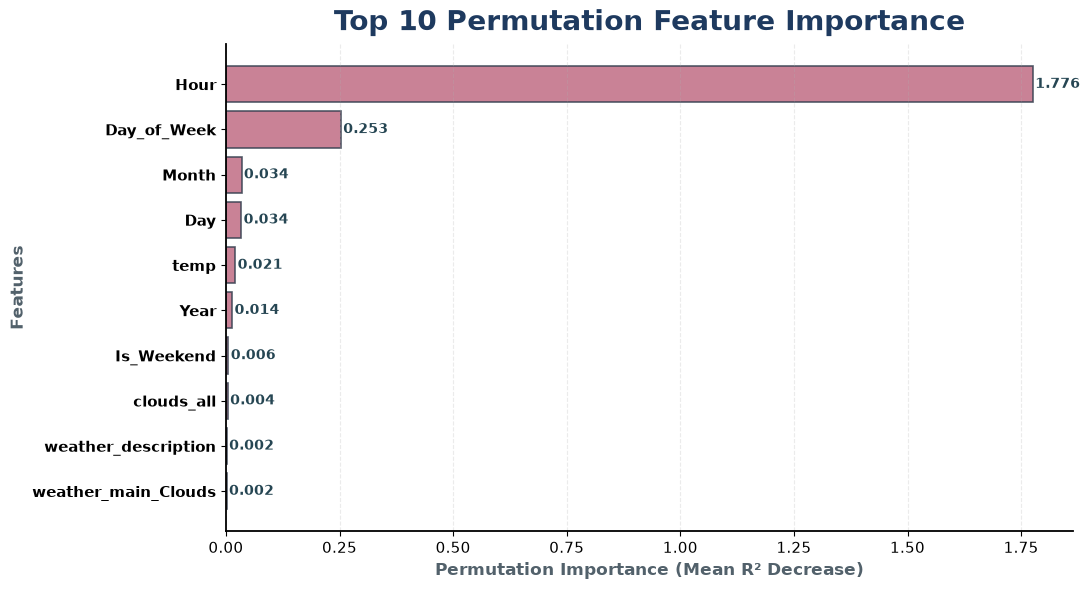

In [448]:
top_10_perm = permutation_importance.sort_values(
    by='Importance',
    ascending=True
)

plt.figure(figsize=(11, 6))

bars = plt.barh(
    top_10_perm["Feature"],
    top_10_perm["Importance"],
    color='#C06C84',
    edgecolor='#374151',
    linewidth=1.2,
    alpha=0.85
)

plt.title(
    "Top 10 Permutation Feature Importance",
    fontsize=20,
    fontweight='bold',
    color='#1E3A5F',
    pad=10
)

plt.xlabel(
    "Permutation Importance (Mean R² Decrease)",
    fontsize=12,
    fontweight='bold',
    color='#52616B'
)

plt.ylabel(
    "Features",
    fontsize=12,
    fontweight='bold',
    color='#52616B'
)

plt.grid(
    axis='x',
    linestyle='--',
    linewidth=0.8,
    alpha=0.25
)

plt.xticks(fontsize=11)
plt.yticks(
    fontsize=11,
    fontweight='bold'
)

# Remove border
ax = plt.gca()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_linewidth(1.3)
ax.spines['bottom'].set_linewidth(1.3)

# Value Labels
for bar in bars:
    width = bar.get_width()

    plt.text(
        width + (top_10_perm["Importance"].max() * 0.003),
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va='center',
        ha='left',
        color='#264653',
        fontweight='bold',
        fontsize=10
    )

plt.tight_layout()
plt.show()

###

### **Saving the Final Tuned LightGBM Model**

In [450]:
import joblib

joblib.dump(lgbm_tuned, "Final_model_lgbm_tuned.pkl")

['Final_model_lgbm_tuned.pkl']

### **Saving the Frequency Encoding Mapping**

In [451]:
joblib.dump(freq_mapping, "freq_mapping.pkl")

['freq_mapping.pkl']

### **Saving the Model Feature Columns**

In [452]:
feature_columns = X.columns.tolist()

joblib.dump(feature_columns, "feature_columns.pkl")

['feature_columns.pkl']

In [453]:
X.columns

Index(['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_description',
       'Hour', 'Day', 'Month', 'Year', 'Day_of_Week', 'Is_Weekend',
       'holiday_Columbus Day', 'holiday_Independence Day', 'holiday_Labor Day',
       'holiday_Martin Luther King Jr Day', 'holiday_Memorial Day',
       'holiday_New Years Day', 'holiday_No Holiday', 'holiday_State Fair',
       'holiday_Thanksgiving Day', 'holiday_Veterans Day',
       'holiday_Washingtons Birthday', 'weather_main_Clouds',
       'weather_main_Drizzle', 'weather_main_Fog', 'weather_main_Haze',
       'weather_main_Mist', 'weather_main_Rain', 'weather_main_Smoke',
       'weather_main_Snow', 'weather_main_Squall',
       'weather_main_Thunderstorm'],
      dtype='object')

In [491]:
df['Is_Weekend'].unique()

array([0, 1])

In [455]:
X.columns.tolist()

['temp',
 'rain_1h',
 'snow_1h',
 'clouds_all',
 'weather_description',
 'Hour',
 'Day',
 'Month',
 'Year',
 'Day_of_Week',
 'Is_Weekend',
 'holiday_Columbus Day',
 'holiday_Independence Day',
 'holiday_Labor Day',
 'holiday_Martin Luther King Jr Day',
 'holiday_Memorial Day',
 'holiday_New Years Day',
 'holiday_No Holiday',
 'holiday_State Fair',
 'holiday_Thanksgiving Day',
 'holiday_Veterans Day',
 'holiday_Washingtons Birthday',
 'weather_main_Clouds',
 'weather_main_Drizzle',
 'weather_main_Fog',
 'weather_main_Haze',
 'weather_main_Mist',
 'weather_main_Rain',
 'weather_main_Smoke',
 'weather_main_Snow',
 'weather_main_Squall',
 'weather_main_Thunderstorm']